# Final Project
## Machine Learning for Neuroscience
### Gaia Negev and Tzlil Tabib

In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import shap
import warnings
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc as sklearn_auc
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import (adjusted_rand_score, silhouette_score, roc_curve, roc_auc_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer  

# Initial Data Handling
Loading, organizing and dividing to train and test

In [ ]:
# load data from json
with open('data/emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# data to pd.DataFrame
df = pd.DataFrame(data)
df_annotations = pd.DataFrame(df['annotations'].tolist())
df = pd.concat([df.drop('annotations', axis=1), df_annotations], axis=1)
df.head()

# remove image_name column because it's duplicated in image_id
df = df.drop('image_name', axis=1)
# make image_id the index
df = df.set_index('image_id')
df.head()

# divide data to train and test - stratified by emotion (insure that all emotions are represented in both sets)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

# save division to csv
train_df.to_csv('data/train.csv')
test_df.to_csv('data/test.csv')

In [ ]:
# load the data 
train_df = pd.read_csv('data/train.csv', index_col='image_id')
test_df = pd.read_csv('data/test.csv', index_col='image_id')

# EDA

In [4]:
train_df.info()

# null analysis
train_df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 800 entries, excitement_02550 to disgust_07992
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   description                800 non-null    str    
 1   embedding                  800 non-null    str    
 2   viewer_feelings            800 non-null    str    
 3   description_embedding      800 non-null    str    
 4   viewer_feelings_embedding  800 non-null    str    
 5   emotion                    800 non-null    str    
 6   brightness                 799 non-null    float64
 7   colorfulness               778 non-null    float64
 8   facial_expression          88 non-null     str    
 9   object                     412 non-null    str    
 10  human_action               86 non-null     str    
 11  scene                      173 non-null    str    
dtypes: float64(2), str(10)
memory usage: 81.2+ KB


description                    0
embedding                      0
viewer_feelings                0
description_embedding          0
viewer_feelings_embedding      0
emotion                        0
brightness                     1
colorfulness                  22
facial_expression            712
object                       388
human_action                 714
scene                        627
dtype: int64

                           null_count  null_pct
human_action                      714      89.2
facial_expression                 712      89.0
scene                             627      78.4
object                            388      48.5
colorfulness                       22       2.8
brightness                          1       0.1
embedding                           0       0.0
description                         0       0.0
description_embedding               0       0.0
viewer_feelings                     0       0.0
viewer_feelings_embedding           0       0.0
emotion                             0       0.0


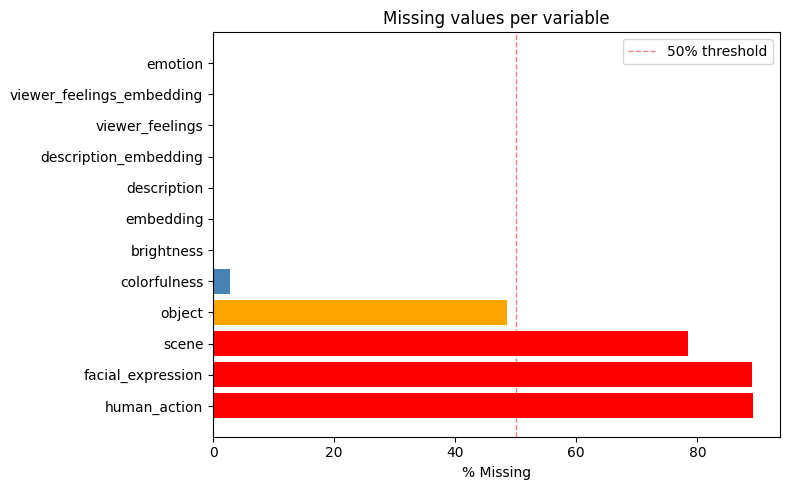

In [5]:
total = len(train_df)
null_counts = train_df.isnull().sum()
null_pct = (null_counts / total * 100).round(1)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).sort_values('null_pct', ascending=False)

print(null_summary.to_string())

# Plot
plt.figure(figsize=(8, 5))
colors = ['red' if p > 50 else 'orange' if p > 10 else 'steelblue' 
          for p in null_summary['null_pct']]
plt.barh(null_summary.index, null_summary['null_pct'], color=colors)
plt.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
plt.xlabel('% Missing')
plt.title('Missing values per variable')
plt.legend()
plt.tight_layout()
plt.show()

Since most of the samples are missing facial_expression, human_action and scence - we'll consider leaving these variables out of the analysis. 

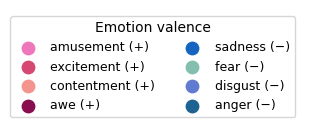

In [6]:
# Emotion valence mapping - color coding in visualizations
# Positive emotions → warm colors
# Negative emotions → cool colors

emotion_colors = {
    'amusement':   "#EE77BC", 
    'excitement':  "#D64772", 
    'contentment': "#F3958E", 
    'awe':         '#880E4F', 
    'sadness':     '#1565C0', 
    'fear':        "#84BEAD",  
    'disgust':     "#617BD1", 
    'anger':       "#1E6391",  
}
# Canonical emotion order (alphabetical, matches LabelEncoder)
encoder_order = sorted(emotion_colors.keys())

def plot_emotion_legend(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 1))
    
    positive = ['amusement', 'excitement', 'contentment', 'awe']
    negative = ['sadness', 'fear', 'disgust', 'anger']
    
    for i, e in enumerate(positive):
        ax.scatter([], [], color=emotion_colors[e], label=f'{e} (+)', s=80)
    for i, e in enumerate(negative):
        ax.scatter([], [], color=emotion_colors[e], label=f'{e} (−)', s=80)
    
    ax.legend(ncol=2, fontsize=9, title='Emotion valence')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_emotion_legend()

emotion
excitement     100
awe            100
disgust        100
contentment    100
fear           100
sadness        100
anger          100
amusement      100
Name: count, dtype: int64


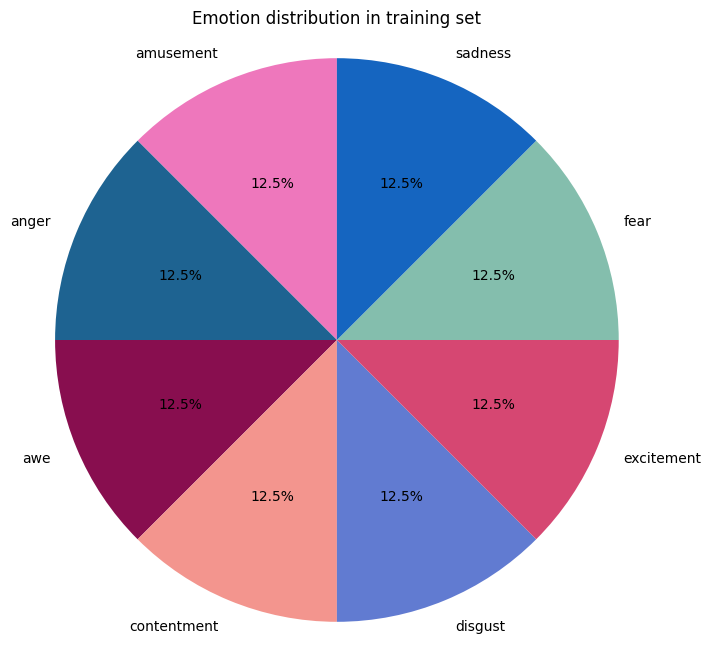

In [7]:
# emotion distribution to see if there is a class imbalance
emotion_counts = train_df['emotion'].value_counts()
print(emotion_counts)

emotion_counts_ordered = train_df['emotion'].value_counts().reindex(encoder_order)
plt.figure(figsize=(8, 8))
plt.pie(
    emotion_counts_ordered,
    labels=emotion_counts_ordered.index,
    colors=[emotion_colors[e] for e in emotion_counts_ordered.index],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Emotion distribution in training set')
plt.axis('equal')
plt.show()

The emotion classes are relatively balanced (each ~12-13%), so we do not apply class weighting in our models. With roughly equal representation, standard loss functions are not biased toward majority classes, and macro-averaged metrics remain meaningful without reweighting.

# Data Preprocessing Plan 
1. Numeric variables: brightness, colorfulness; standarize and fill nulls using median
2. Category variables: emotion; label encoding
3. Text variables: description, viewer_feelings, object; tfidf

## Data Preprocessing
Below we visualize numeric variables and prepare text features. Note that all fitted transformers (scaler, imputer, TF-IDF) are applied to the test set via `.transform()` only.

## Numerics Variables

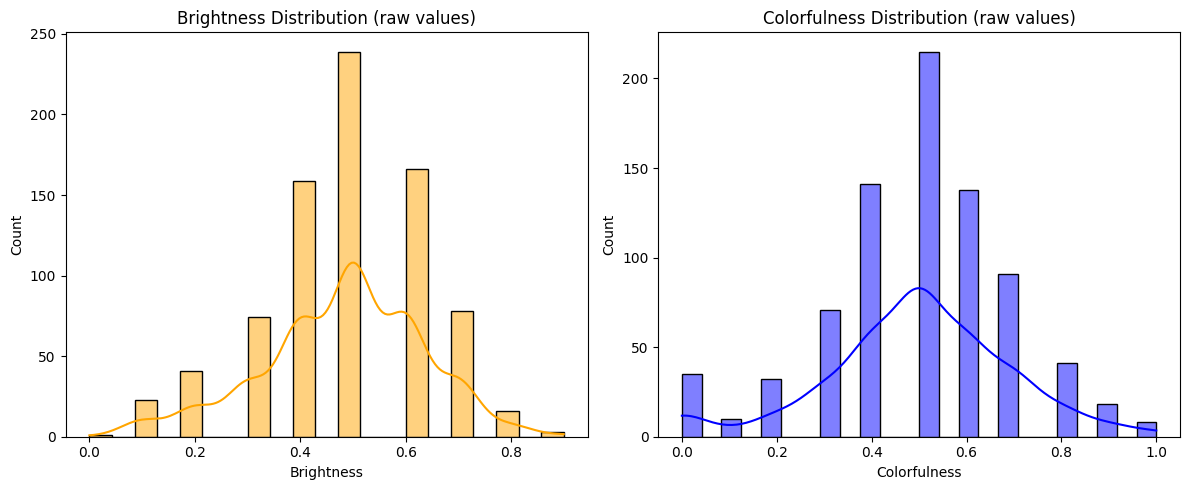

Correlation between brightness and colorfulness: 0.25


In [8]:
train_df.describe()

brightness_col = train_df['brightness'].fillna(train_df['brightness'].median())
colorfulness_col = train_df['colorfulness'].fillna(train_df['colorfulness'].median())
X_numeric_eda = np.column_stack([brightness_col, colorfulness_col])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_numeric_eda[:, 0], kde=True, color='orange')
plt.title('Brightness Distribution (raw values)')
plt.xlabel('Brightness')
plt.subplot(1, 2, 2)
sns.histplot(X_numeric_eda[:, 1], kde=True, color='blue')
plt.title('Colorfulness Distribution (raw values)')
plt.xlabel('Colorfulness')
plt.tight_layout()
plt.show()

print(f"Correlation between brightness and colorfulness: {np.corrcoef(X_numeric_eda[:, 0], X_numeric_eda[:, 1])[0, 1]:.2f}")

We see a low correlation between brightness and colorfulness, suggesting each holds unique information.

## Labeling emotion - target variable

In [9]:
# Encode emotion labels
le_eda = LabelEncoder()
target = le_eda.fit_transform(train_df['emotion'])
# Verify label order matches canonical encoder_order
assert list(le_eda.classes_) == encoder_order, "Label order mismatch!"


## Text Variables - TFIDF
We treat `max_features` of the TF-IDF as a hyperparameter. To select it, we evaluate CV AUC across a coarse grid (steps of 30) and identify the **elbow point** — the last value where adding more features yields a marginal AUC gain above 0.005 per step. A finer grid (steps of 10) is overlaid to confirm no meaningful gains were missed between coarse steps. This approach favors parsimony: beyond the elbow, the curve flattens and additional features increase model complexity with negligible performance benefit, raising the risk of overfitting on a relatively small dataset (N≈800).

In [10]:
# Text preprocessing functions for combined text features
def prefix_text(text, prefix):
    """Prefix each non-stopword token with a source tag (e.g., desc_, feel_)."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    words = [w for w in text.lower().split() if w not in ENGLISH_STOP_WORDS]
    return ' '.join(f"{prefix}_{w}" for w in words)

def prefix_object_list(text, prefix):
    """Handle object column which contains list strings like ['Tree', 'Plant']."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    try:
        items = ast.literal_eval(text)
        if isinstance(items, list):
            words = [item.lower().strip() for item in items if item.strip()]
            return ' '.join(f"{prefix}_{w}" for w in words)
    except Exception:
        pass
    return prefix_text(text, prefix)

def build_combined_text(df):
    """Build the combined text column from description, viewer_feelings, and object columns."""
    df = df.copy()
    for col in ['description', 'viewer_feelings', 'object']:
        df[col] = df[col].fillna('')
    combined = (
        df['description'].apply(lambda x: prefix_text(x, 'desc')) + ' ' +
        df['viewer_feelings'].apply(lambda x: prefix_text(x, 'feel')) + ' ' +
        df['object'].apply(lambda x: prefix_object_list(x, 'obj'))
    )
    return combined

train_df['combined_text'] = build_combined_text(train_df)

c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

max_features=  50 — AUC mean=0.888  std=0.011


c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

max_features=  80 — AUC mean=0.909  std=0.012
max_features= 110 — AUC mean=0.919  std=0.009


c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

...

max_features= 170 — AUC mean=0.926  std=0.009
max_features= 200 — AUC mean=0.934  std=0.008


c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

max_features= 230 — AUC mean=0.936  std=0.007


c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\final_project_machine_learning\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov


Selected max_features (coarse elbow): 110


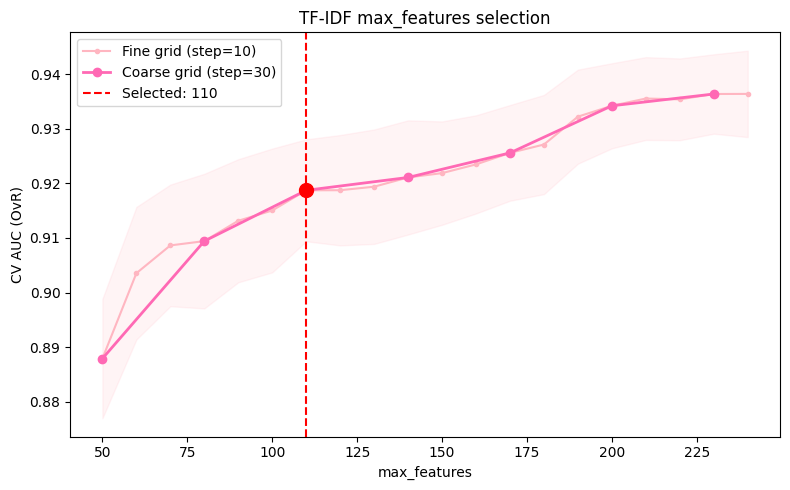


Final TF-IDF shape: (800, 110)


In [11]:
# silence warnings for cleaner output during CV
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# ── Tune max_features via CV ─────────────────────────────────────────────────
# TF-IDF is fit on the full training set before CV here. This is a known
# source of mild optimistic bias (see limitations note). The final evaluation
# relies on the held-out test set.

max_features_coarse = list(range(50, 250, 30))
cv_tfidf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tfidf_cv_coarse = {}

for mf in max_features_coarse:
    tfidf_temp = TfidfVectorizer(max_features=mf)
    X_temp = tfidf_temp.fit_transform(train_df['combined_text'])
    # Combine with raw numeric (impute + scale inside this quick loop)
    numeric_raw = train_df[['brightness', 'colorfulness']].fillna(train_df[['brightness', 'colorfulness']].median()).values
    scaler_temp = StandardScaler()
    numeric_scaled = scaler_temp.fit_transform(numeric_raw)
    X_temp_full = hstack([X_temp, csr_matrix(numeric_scaled)])
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_temp_full, target, cv=cv_tfidf, scoring='roc_auc_ovr'
    )
    tfidf_cv_coarse[mf] = scores
    print(f"max_features={mf:4d} — AUC mean={scores.mean():.3f}  std={scores.std():.3f}")

# ── Fine grid for validation ─────────────────────────────────────────────────
max_features_fine = list(range(50, 250, 10))
tfidf_cv_fine = {}
for mf in max_features_fine:
    tfidf_temp = TfidfVectorizer(max_features=mf)
    X_temp = tfidf_temp.fit_transform(train_df['combined_text'])
    numeric_raw = train_df[['brightness', 'colorfulness']].fillna(train_df[['brightness', 'colorfulness']].median()).values
    scaler_temp = StandardScaler()
    numeric_scaled = scaler_temp.fit_transform(numeric_raw)
    X_temp_full = hstack([X_temp, csr_matrix(numeric_scaled)])
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_temp_full, target, cv=cv_tfidf, scoring='roc_auc_ovr'
    )
    tfidf_cv_fine[mf] = scores

# ── Elbow selection on coarse grid ───────────────────────────────────────────
means_c = np.array([tfidf_cv_coarse[mf].mean() for mf in max_features_coarse])
marginal_c = np.diff(means_c)
gain_threshold = 0.005

best_max_features = max_features_coarse[0]
for j in range(len(marginal_c)):
    if marginal_c[j] >= gain_threshold:
        best_max_features = max_features_coarse[j + 1]
    else:
        break

print(f"\nSelected max_features (coarse elbow): {best_max_features}")

# ── Plot ─────────────────────────────────────────────────────────────────────
means_f = np.array([tfidf_cv_fine[mf].mean() for mf in max_features_fine])
stds_f  = np.array([tfidf_cv_fine[mf].std() for mf in max_features_fine])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(max_features_fine, means_f, marker='.', color='lightpink', linewidth=1.5, label='Fine grid (step=10)')
ax.fill_between(max_features_fine, means_f - stds_f, means_f + stds_f, alpha=0.15, color='lightpink')
ax.plot(max_features_coarse, means_c, marker='o', color='hotpink', linewidth=2, label='Coarse grid (step=30)')
ax.axvline(best_max_features, color='red', linestyle='--', linewidth=1.5, label=f'Selected: {best_max_features}')
ax.scatter([best_max_features], [means_c[max_features_coarse.index(best_max_features)]],
           color='red', s=100, zorder=5)
ax.set_xlabel('max_features')
ax.set_ylabel('CV AUC (OvR)')
ax.set_title('TF-IDF max_features selection')
ax.legend()
plt.tight_layout()
plt.show()

# ── Fit final TF-IDF ────────────────────────────────────────────────────────
tfidf_combined = TfidfVectorizer(max_features=best_max_features)
combined_matrix = tfidf_combined.fit_transform(train_df['combined_text'])
print(f"\nFinal TF-IDF shape: {combined_matrix.shape}")

In [12]:
# present the first 5 rows of combined_matrix
combined_df = pd.DataFrame(combined_matrix[:5].toarray(), columns=tfidf_combined.get_feature_names_out())
print(combined_df.head())
print(combined_df.columns)

   desc_  desc_backdrop  desc_background  desc_black  desc_blue  desc_blurred  \
0    0.0       0.382019         0.000000    0.332801        0.0           0.0   
1    0.0       0.000000         0.000000    0.000000        0.0           0.0   
2    0.0       0.000000         0.000000    0.000000        0.0           0.0   
3    0.0       0.000000         0.000000    0.000000        0.0           0.0   
4    0.0       0.000000         0.222311    0.000000        0.0           0.0   

   desc_clear  desc_close  desc_colorful  desc_dark  ...  feel_unease  \
0         0.0         0.0            0.0        0.0  ...          0.0   
1         0.0         0.0            0.0        0.0  ...          0.0   
2         0.0         0.0            0.0        0.0  ...          0.0   
3         0.0         0.0            0.0        0.0  ...          0.0   
4         0.0         0.0            0.0        0.0  ...          0.0   

   feel_vibrant  feel_viewer  feel_warmth  feel_watching  feel_witnessing 

## Clustering & Dimensionality Reduction
We examine whether the emotion categories form natural clusters in the embedding space before any supervised learning. We apply K-Means (k=8, matching the number of emotions) and compare cluster assignments to true labels using the Adjusted Rand Index. We also visualize the embedding space using PCA and t-SNE.

Adjusted Rand Index (clusters vs. true emotions): 0.318
Silhouette Score: 0.104

Contingency table (rows=true emotions, cols=clusters):
Cluster        0   1   2   3   4   5   6   7
True emotion                                
amusement      0  25   9   0   9   0  57   0
anger         35   5   0   3  21  20   1  15
awe            0   9  77   2   8   1   1   2
contentment    0  54  40   0   0   1   4   1
disgust        0   0   2  45   0  27   7  19
excitement     0  23   3   0  73   0   1   0
fear           1   1   1   8   0   9   7  73
sadness        0  14   5  53   2   3   3  20


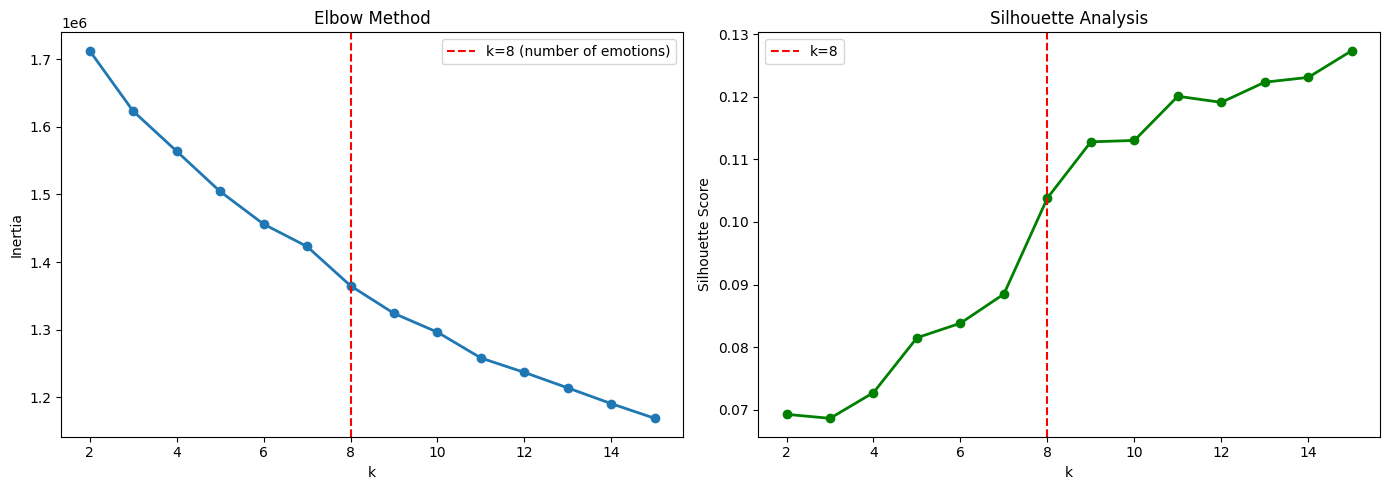

In [13]:
# Parse embeddings for EDA (needed before modeling section)
train_df['embedding_parsed'] = train_df['embedding'].apply(ast.literal_eval)
train_df['desc_emb_parsed'] = train_df['description_embedding'].apply(ast.literal_eval)
train_df['feel_emb_parsed'] = train_df['viewer_feelings_embedding'].apply(ast.literal_eval)

E_image_eda = np.stack(train_df['embedding_parsed'].values)
E_desc_eda  = np.stack(train_df['desc_emb_parsed'].values)
E_feel_eda  = np.stack(train_df['feel_emb_parsed'].values)

# Standardize for EDA
scaler_eda_img  = StandardScaler()
scaler_eda_desc = StandardScaler()
scaler_eda_feel = StandardScaler()
E_img_s  = scaler_eda_img.fit_transform(E_image_eda)
E_desc_s = scaler_eda_desc.fit_transform(E_desc_eda)
E_feel_s = scaler_eda_feel.fit_transform(E_feel_eda)

# Quick PCA to manageable dimensions for clustering
pca_eda_img  = PCA(n_components=50, random_state=42).fit_transform(E_img_s)
pca_eda_desc = PCA(n_components=50, random_state=42).fit_transform(E_desc_s)
pca_eda_feel = PCA(n_components=50, random_state=42).fit_transform(E_feel_s)
X_eda_combined = np.hstack([pca_eda_img, pca_eda_desc, pca_eda_feel])

# ── 1. K-Means clustering (k=8) ─────────────────────────────────────────────
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_eda_combined)

ari = adjusted_rand_score(target, cluster_labels)
sil = silhouette_score(X_eda_combined, cluster_labels, sample_size=min(800, len(target)))
print(f"Adjusted Rand Index (clusters vs. true emotions): {ari:.3f}")
print(f"Silhouette Score: {sil:.3f}")

# ── 2. Contingency table: clusters vs true emotions ─────────────────────────
contingency = pd.crosstab(
    pd.Series(target, name='True emotion').map(dict(enumerate(encoder_order))),
    pd.Series(cluster_labels, name='Cluster')
)
print("\nContingency table (rows=true emotions, cols=clusters):")
print(contingency)

# ── 3. Elbow plot: try different k values ────────────────────────────────────
k_range = range(2, 16)
inertias = []
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_eda_combined)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_eda_combined, km.labels_, sample_size=min(800, len(target))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker='o', linewidth=2)
axes[0].axvline(8, color='red', linestyle='--', label='k=8 (number of emotions)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].legend()

axes[1].plot(k_range, sil_scores, marker='o', linewidth=2, color='green')
axes[1].axvline(8, color='red', linestyle='--', label='k=8')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\tzlil\AppData\Local\Temp\ipykernel_2460\199463778.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = plt.cm.get_cmap('tab10', 8)


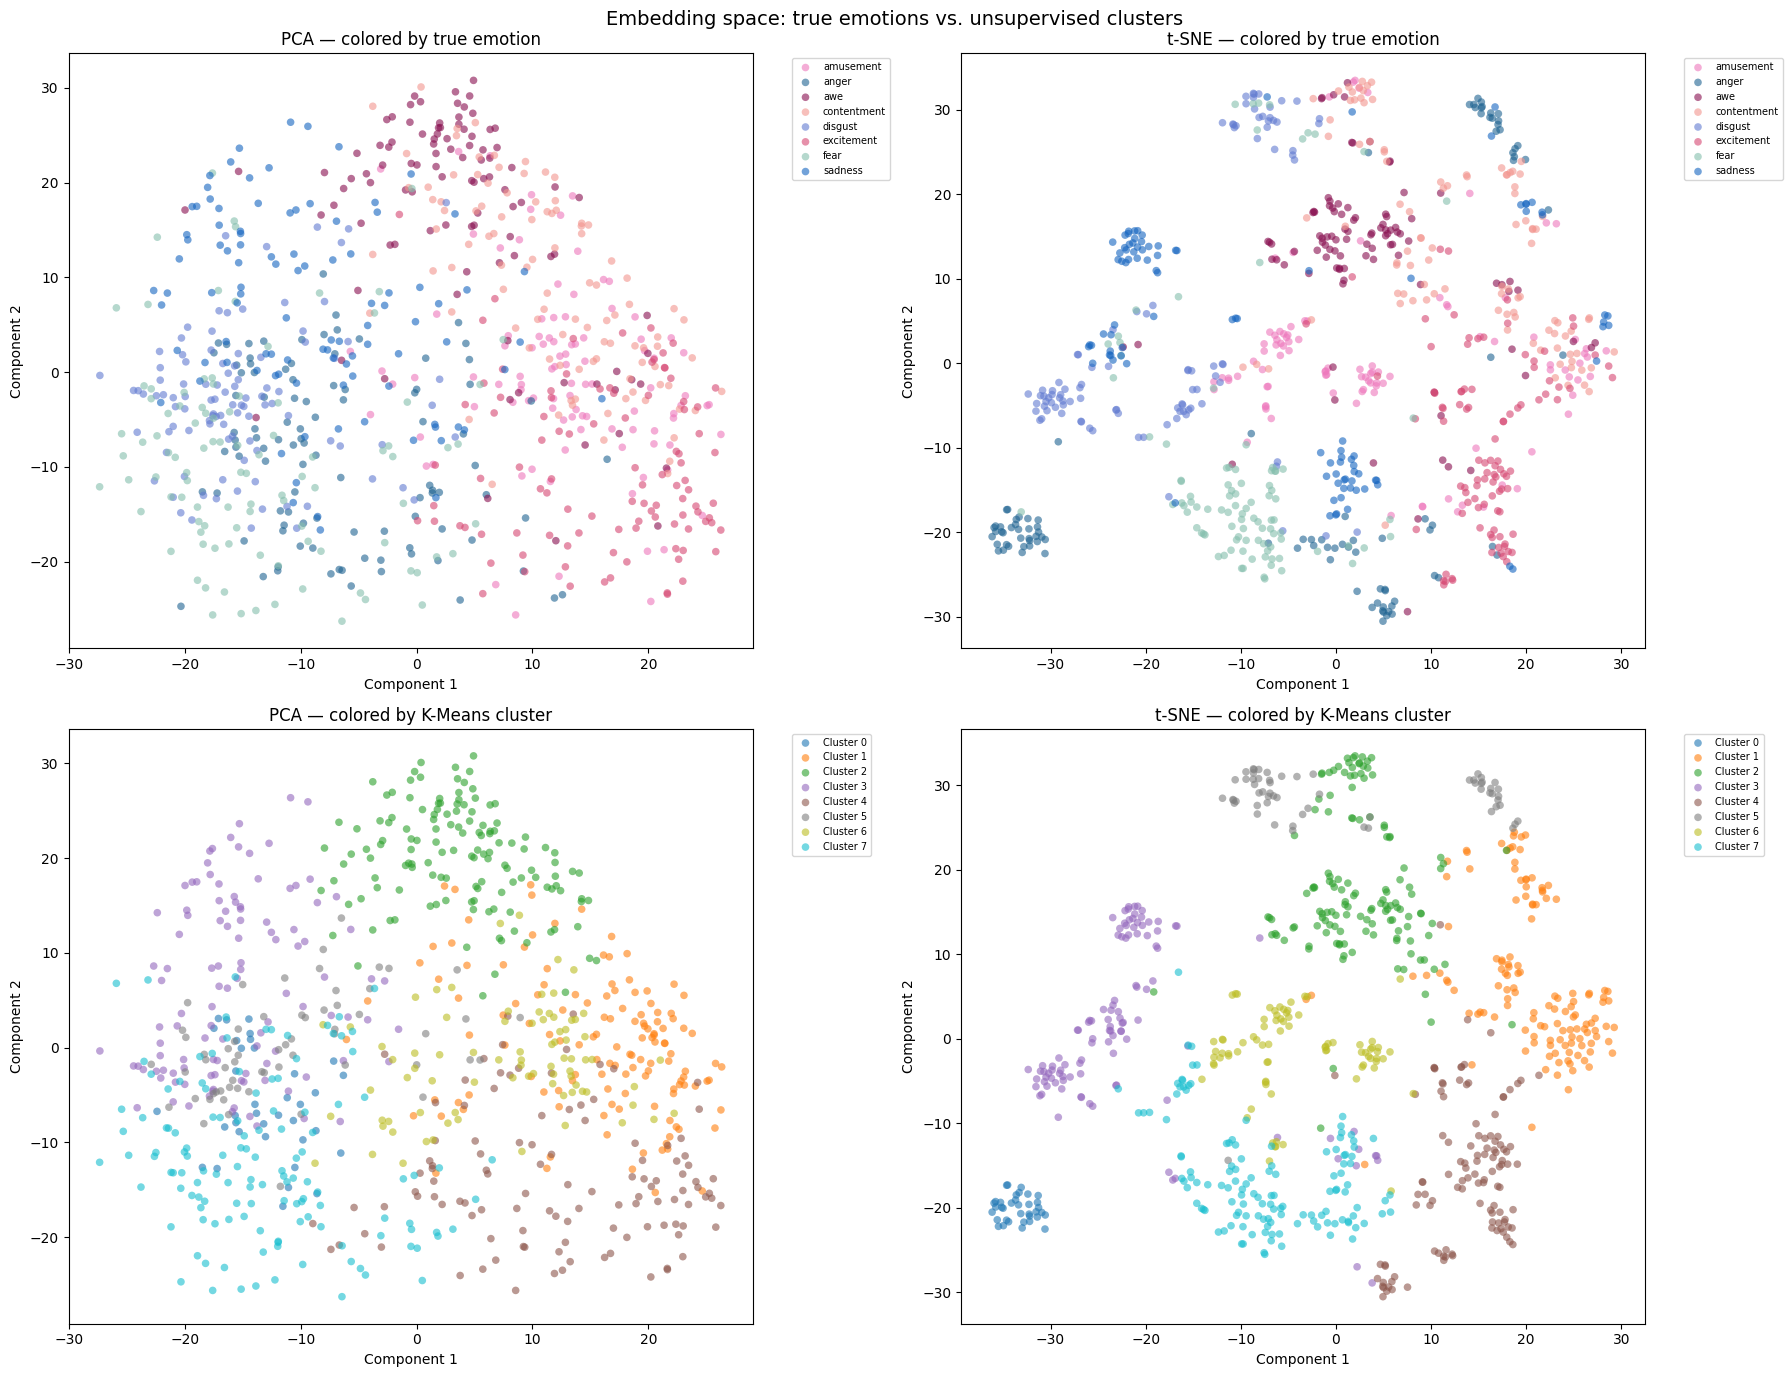

In [14]:
# # ── Dimensionality reduction visualization ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d_pca = pca_2d.fit_transform(X_eda_combined)

# t-SNE 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_2d_tsne = tsne.fit_transform(X_eda_combined)

# Top row: colored by true emotion
for ax, X_2d, title in zip(axes[0], [X_2d_pca, X_2d_tsne], ['PCA', 't-SNE']):
    for idx, emotion in enumerate(encoder_order):
        mask = target == idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=emotion,
                   color=emotion_colors[emotion],
                   alpha=0.6, s=30, edgecolors='none')
    ax.set_title(f'{title} — colored by true emotion', fontsize=12)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

# Bottom row: colored by K-Means cluster
cluster_cmap = plt.cm.get_cmap('tab10', 8)
for ax, X_2d, title in zip(axes[1], [X_2d_pca, X_2d_tsne], ['PCA', 't-SNE']):
    for c in range(8):
        mask = cluster_labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=f'Cluster {c}',
                   color=cluster_cmap(c),
                   alpha=0.6, s=30, edgecolors='none')
    ax.set_title(f'{title} — colored by K-Means cluster', fontsize=12)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Embedding space: true emotions vs. unsupervised clusters', fontsize=14)
plt.tight_layout()
plt.show()

The Adjusted Rand Index indicates the degree of agreement between unsupervised K-Means clusters and the true emotion labels. A moderate ARI suggests that while the embedding space captures some of the emotion structure, the eight discrete emotion categories do not map cleanly onto separable clusters — consistent with the dimensional view of affect where emotions blend along valence and arousal axes rather than forming discrete islands. The t-SNE plot shows some separation (particularly between positive and negative valence), but considerable overlap between within-valence emotions like fear/anger or amusement/excitement.

# Modeling 

## 1. Tabular model

### Model comparison
*Preprocessing (imputation, scaling, TF-IDF) and modeling with fitted objects from the training set (with a dummy baseline).*

In [15]:
warnings.filterwarnings('ignore')

# Assemble features and add DummyClassifier baseline.
# Numeric imputation + scaling was done above for EDA; here we refit
# a proper scaler on the training set for modeling.

# Prepare numeric features (impute + scale)
numeric_train = train_df[['brightness', 'colorfulness']].copy()
imputer_numeric = SimpleImputer(strategy='median')
scaler_numeric = StandardScaler()
X_numeric_scaled = scaler_numeric.fit_transform(
    imputer_numeric.fit_transform(numeric_train)
)

X_train = hstack([combined_matrix, csr_matrix(X_numeric_scaled)])
y_train = target
print(f"Feature matrix shape: {X_train.shape}")

# ── Define models with hyperparameter grids ────────────────────────────────
coarse_grids = {
    'Dummy (stratified)': (
        DummyClassifier(strategy='stratified', random_state=42),
        {}
    ),
    'Dummy (most frequent)': (
        DummyClassifier(strategy='most_frequent'),
        {}
    ),
    'Logistic Regression (L1)': (
        LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Logistic Regression (L2)': (
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 10]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5]}
    ),
}

# ── CV evaluation ─────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
models = {}

for name, (model, grid) in coarse_grids.items():
    if grid:
        gs = GridSearchCV(model, grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_
        best_params = gs.best_params_
    else:
        best = model
        best.fit(X_train, y_train)
        best_params = {}

    acc  = cross_val_score(best, X_train, y_train, cv=cv, scoring='accuracy')
    auc  = cross_val_score(best, X_train, y_train, cv=cv, scoring='roc_auc_ovr')

    results[name] = {
        'accuracy': acc,
        'auc':      auc,
        'best_params': best_params,
    }
    models[name] = best

    print(f"\n{name}  best_params={best_params}")
    print(f"  accuracy   mean={acc.mean():.3f}  std={acc.std():.3f}")
    print(f"  auc        mean={auc.mean():.3f}  std={auc.std():.3f}")

# ── Select best real model by AUC (exclude dummies) ──────────────────────
real_models = {k: v for k, v in results.items() if 'Dummy' not in k}
best_model_name = max(real_models, key=lambda x: results[x]['auc'].mean())
best_model = models[best_model_name]
print(f"\n✓ Best model: {best_model_name}  AUC={results[best_model_name]['auc'].mean():.3f}")
print(f"  (Dummy stratified baseline AUC={results['Dummy (stratified)']['auc'].mean():.3f})")

Feature matrix shape: (800, 112)

Dummy (stratified)  best_params={}
  accuracy   mean=0.113  std=0.016
  auc        mean=0.493  std=0.009

Dummy (most frequent)  best_params={}
  accuracy   mean=0.125  std=0.000
  auc        mean=0.500  std=0.000

Logistic Regression (L1)  best_params={'C': 1}
  accuracy   mean=0.579  std=0.014
  auc        mean=0.905  std=0.009

Logistic Regression (L2)  best_params={'C': 1}
  accuracy   mean=0.610  std=0.025
  auc        mean=0.919  std=0.009

Random Forest  best_params={'max_depth': None, 'n_estimators': 200}
  accuracy   mean=0.605  std=0.041
  auc        mean=0.913  std=0.012

Gradient Boosting  best_params={'max_depth': 3, 'n_estimators': 100}
  accuracy   mean=0.588  std=0.038
  auc        mean=0.884  std=0.014

✓ Best model: Logistic Regression (L2)  AUC=0.919
  (Dummy stratified baseline AUC=0.493)


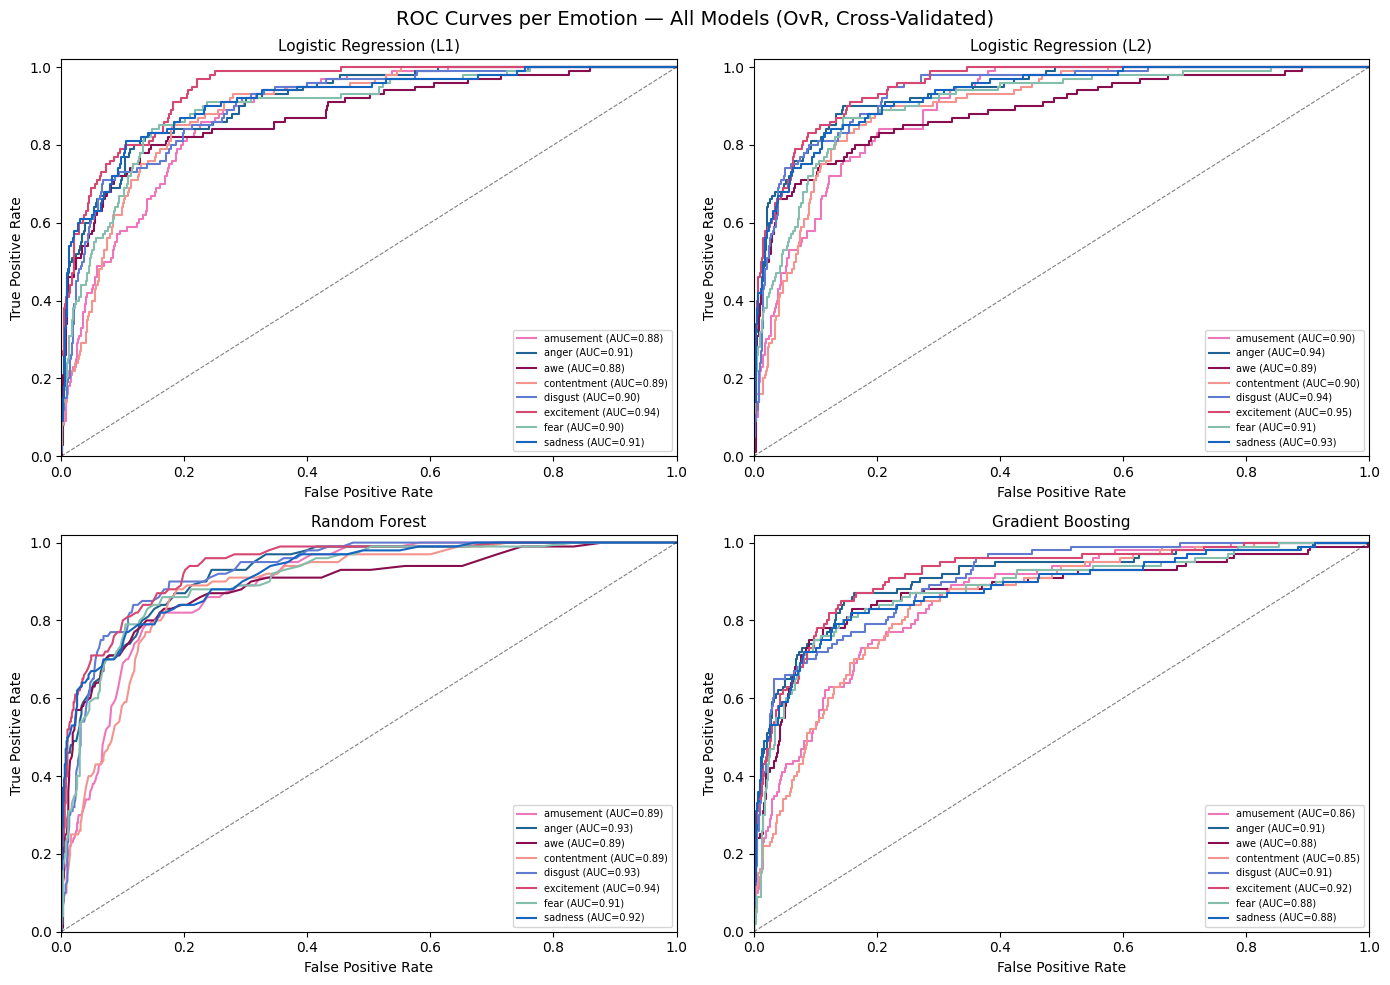

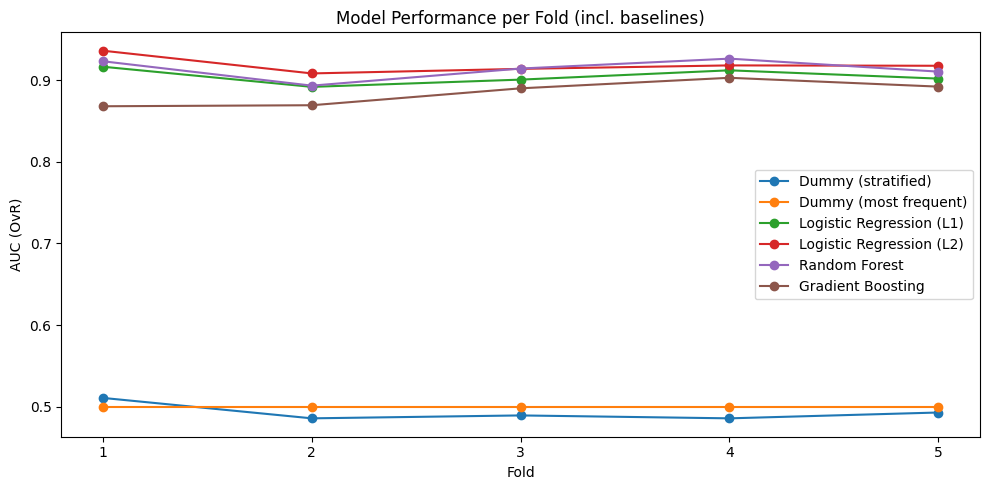

In [16]:
# ── ROC curves (exclude dummy baselines) ───────────────────────────────────
y_bin = label_binarize(y_train, classes=range(len(encoder_order)))

plot_models = {k: v for k, v in models.items() if 'Dummy' not in k}
n_models = len(plot_models)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, plot_models.items()):
    y_prob = cross_val_predict(
        model, X_train, y_train, cv=cv, method='predict_proba'
    )
    for i, emotion in enumerate(encoder_order):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=emotion_colors[emotion], linewidth=1.5,
                label=f"{emotion} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves per Emotion — All Models (OvR, Cross-Validated)', fontsize=14)
plt.tight_layout()
plt.show()

# ── Score per fold plot ────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
for name, metrics in results.items():
    plt.plot(range(1, 6), metrics['auc'], marker='o', label=name)
plt.xlabel('Fold')
plt.xticks(range(1, 6))
plt.ylabel('AUC (OvR)')
plt.title('Model Performance per Fold (incl. baselines)')
plt.legend()
plt.tight_layout()
plt.show()

Logistic Regression (L2) achieved the highest AUC and is also the most interpretable model for feature analysis (direct coefficient inspection + linear SHAP). We therefore proceed with LR for the feature importance and selection stages. The tree-based models showed lower performance on this feature set, likely because the TF-IDF features are high-dimensional and sparse, which suits regularized linear models better than tree-based splitting.

The AUC is substantially higher than accuracy across all models. This is expected in an 8-class problem: AUC (One-vs-Rest, macro) measures each class's ranking ability independently, while accuracy requires the model to commit to a single label. With random-chance accuracy at 12.5% (1/8), even our modest accuracy scores represent meaningful discrimination. The gap between AUC and accuracy suggests the models can distinguish emotional valence and arousal dimensions but struggle with fine-grained categorical boundaries — for example, correctly ranking 'fear' higher than 'amusement' for a fearful image while sometimes mislabeling it as 'disgust' (a neighboring negative emotion)

### Feature importance analysis on the best model

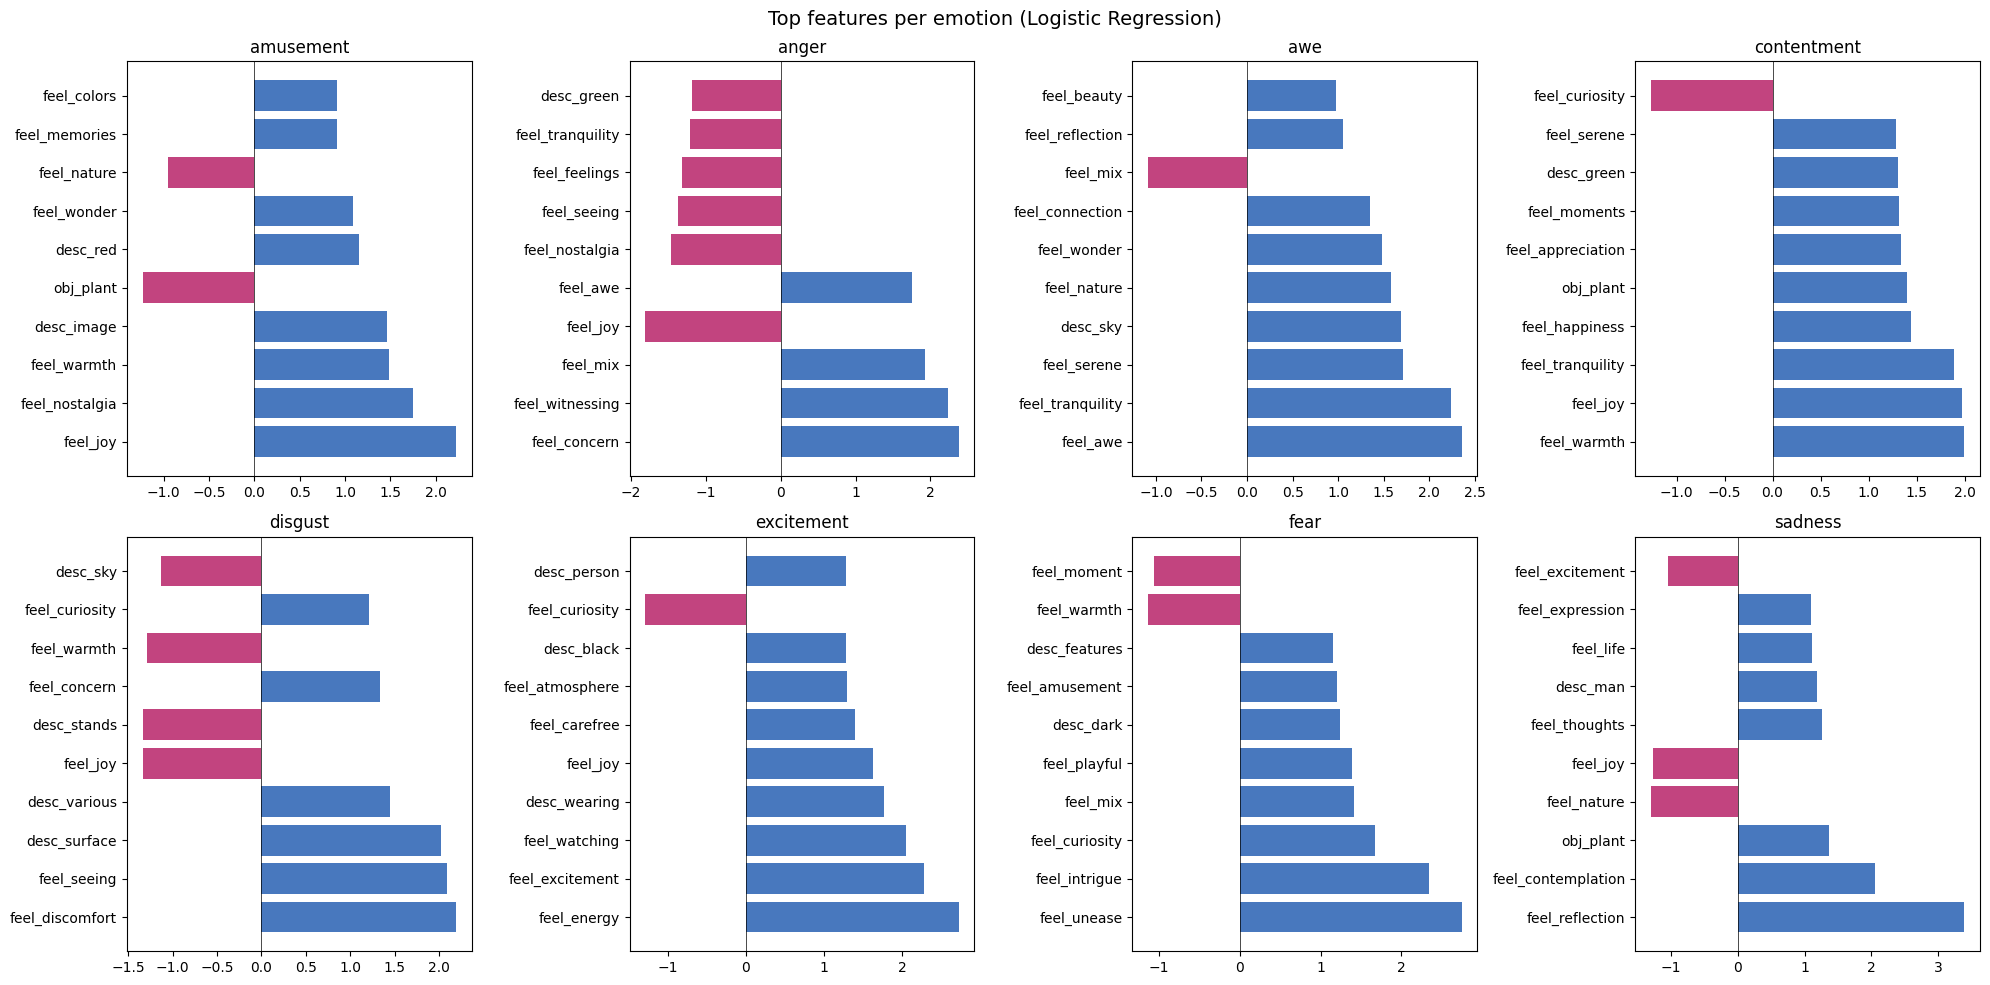

In [17]:
# Get feature names (TF-IDF + numeric)
feature_names = list(tfidf_combined.get_feature_names_out()) + ['brightness', 'colorfulness']

# ── For Logistic Regression ──────────────────────────────────────────────────
# coef_ shape is (n_classes, n_features) - one row per emotion
coef_df = pd.DataFrame(
    best_model.coef_,
    index=encoder_order,
    columns=feature_names
)

# Plot top N features per emotion
n_top = 10
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, emotion in enumerate(encoder_order):
    top_features = coef_df.loc[emotion].abs().nlargest(n_top)
    colors = ['#C2447F' if coef_df.loc[emotion, f] < 0 else "#4878BE" for f in top_features.index]
    axes[i].barh(top_features.index, coef_df.loc[emotion, top_features.index], color=colors)
    axes[i].set_title(emotion)
    axes[i].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Top features per emotion (Logistic Regression)', fontsize=14)
plt.tight_layout()
plt.show()

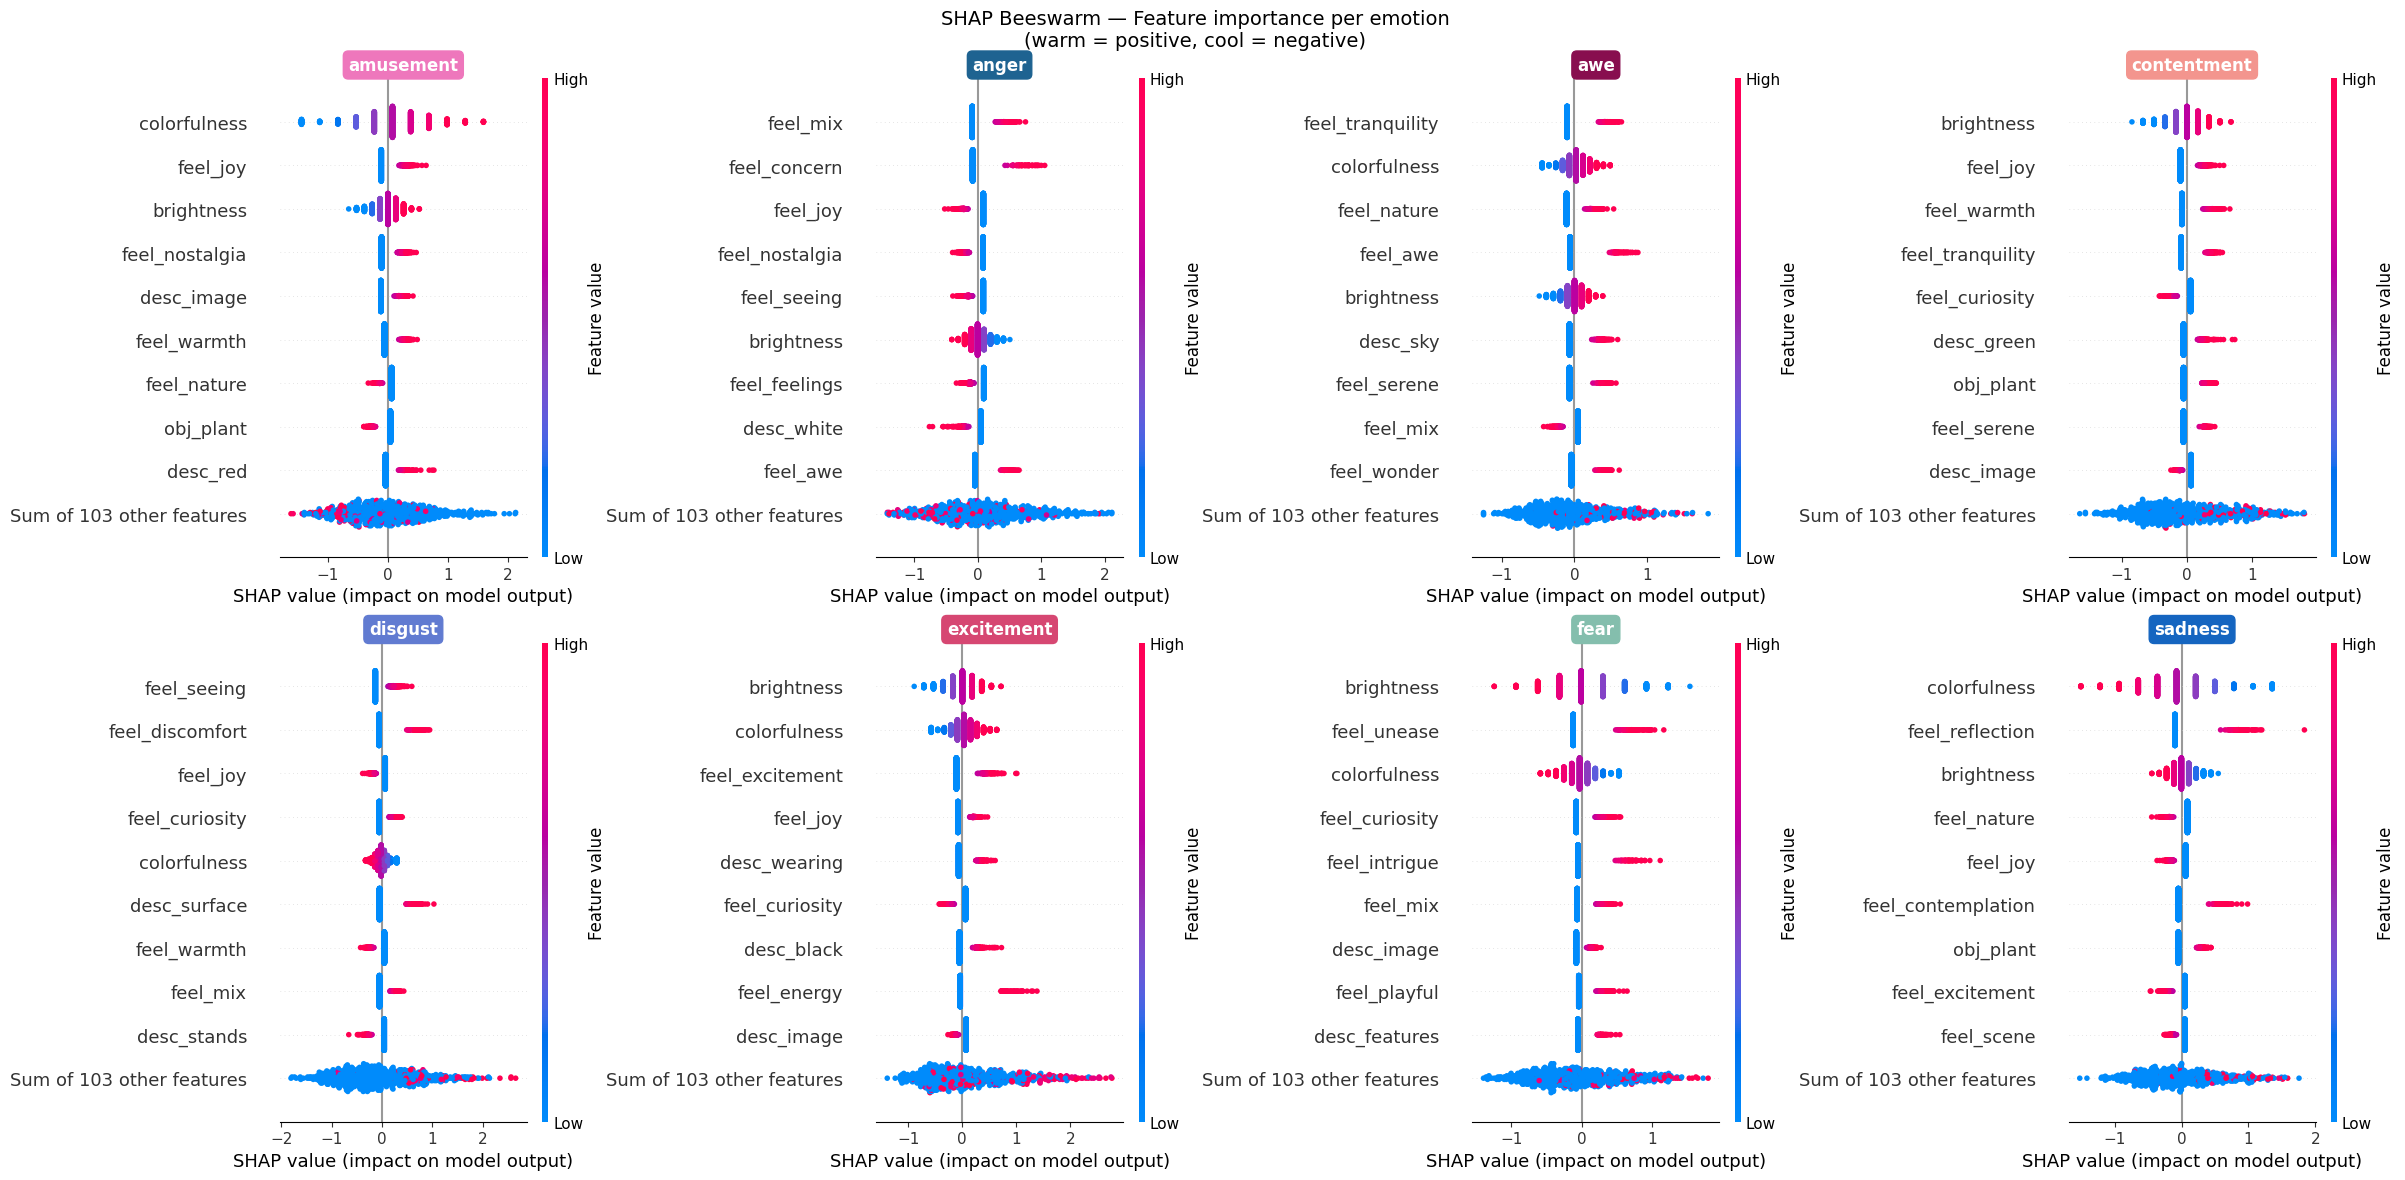

In [18]:
X_train_dense = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names
)

explainer = shap.LinearExplainer(best_model, X_train_dense)
shap_values = explainer(X_train_dense)

# ── Plot all emotions in one figure ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, emotion in enumerate(encoder_order):
    plt.sca(axes[i])  # set current axis for shap to draw on
    
    shap.plots.beeswarm(
        shap_values[:, :, i],
        max_display=10,
        show=False,        # don't render yet
        plot_size=None     # use our axis size
    )
    
    # Add emotion color as a title badge
    color = emotion_colors[emotion]
    axes[i].set_title(emotion, fontsize=12, fontweight='bold',
                      color='white',
                      bbox=dict(facecolor=color, edgecolor=color, 
                                boxstyle='round,pad=0.3'))

plt.suptitle('SHAP Beeswarm — Feature importance per emotion\n(warm = positive, cool = negative)',
             fontsize=14)
plt.tight_layout()
plt.show()

### Feature Selection via SHAP
Having interpreted the model's per-emotion feature importance above, we now use the aggregate SHAP importance to select an optimal feature subset

**Methodological note:** Feature ranking and cutoff selection were performed on the full training set prior to cross-validation, so the cross-validated AUC for the reduced tabular model may be optimistic. Final model quality is therefore interpreted primarily from the held-out test set.

             feature  mean_abs_shap
0       colorfulness       0.195147
1         brightness       0.164097
2           feel_joy       0.109852
3           feel_mix       0.081701
4         desc_image       0.076135
5   feel_tranquility       0.071266
6     feel_curiosity       0.063829
7        feel_nature       0.062461
8        feel_seeing       0.061099
9    feel_excitement       0.059969
10       feel_unease       0.058964
11      feel_concern       0.057882
12   feel_reflection       0.057708
13       feel_warmth       0.057681
14       feel_serene       0.056738
15       feel_moment       0.052420
16          feel_awe       0.050996
17    feel_nostalgia       0.046221
18         obj_plant       0.045952
19          desc_sky       0.044143


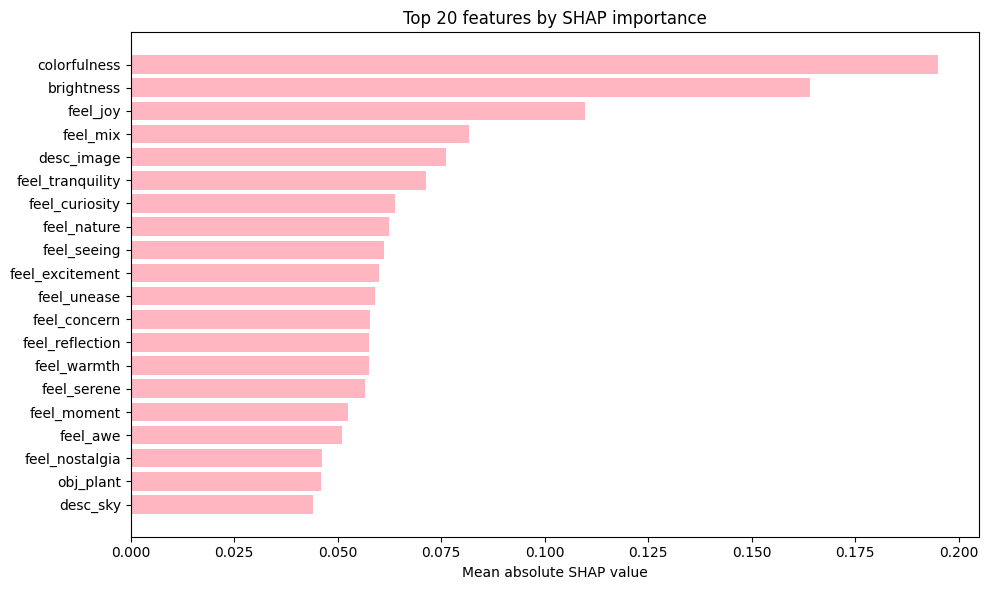

Top  10 features — AUC mean=0.836  std=0.011
Top  20 features — AUC mean=0.889  std=0.004
Top  30 features — AUC mean=0.899  std=0.002
Top  40 features — AUC mean=0.905  std=0.006
Top  50 features — AUC mean=0.909  std=0.007
Top  60 features — AUC mean=0.915  std=0.008
Top  70 features — AUC mean=0.920  std=0.008
Top  80 features — AUC mean=0.921  std=0.008
Top  90 features — AUC mean=0.920  std=0.010
Top 100 features — AUC mean=0.919  std=0.010
Top 110 features — AUC mean=0.919  std=0.009


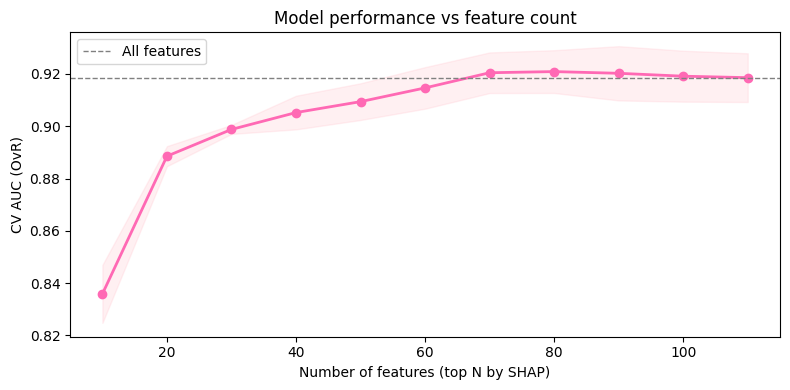

Best cutoff: top 80 features
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 1}
Best CV AUC: 0.921


In [19]:
# ── 1. Get mean absolute SHAP per feature (across all emotions) ──────────────
# shap_values.values shape: (n_samples, n_features, n_classes)
mean_shap_per_feature = np.abs(shap_values.values).mean(axis=(0, 2))  
# average over samples AND classes → shape: (n_features,)

# Create a ranked dataframe
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_shap_per_feature
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(shap_importance_df.head(20))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(shap_importance_df['feature'][:20][::-1], 
         shap_importance_df['mean_abs_shap'][:20][::-1], color='lightpink')
plt.xlabel('Mean absolute SHAP value')
plt.title('Top 20 features by SHAP importance')
plt.tight_layout()
plt.show()

# ── 2. Try different feature cutoffs using CV ────────────────────────────────
# Instead of arbitrarily picking top-N, test several thresholds

cutoffs = range(10, 112, 10)  # test top 10, 20, ..., 112 features
cutoff_results = {}

for n in cutoffs:
    # Select top N feature indices
    top_n_features = shap_importance_df['feature'][:n].tolist()
    top_n_idx = [feature_names.index(f) for f in top_n_features]
    
    # Subset the feature matrix
    X_subset = X_train_dense.iloc[:, top_n_idx]
    
    # CV with best model
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_subset, y_train, cv=cv, scoring='roc_auc_ovr'
    )
    cutoff_results[n] = scores
    print(f"Top {n:3d} features — AUC mean={scores.mean():.3f}  std={scores.std():.3f}")

# ── 3. Plot performance vs number of features ────────────────────────────────
means = [cutoff_results[n].mean() for n in cutoffs]
stds = [cutoff_results[n].std() for n in cutoffs]

plt.figure(figsize=(8, 4))
plt.plot(cutoffs, means, marker='o', color='hotpink', linewidth=2)
plt.fill_between(cutoffs, 
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='lightpink')
plt.axhline(means[-1], color='gray', linestyle='--', linewidth=1, label='All features')
plt.xlabel('Number of features (top N by SHAP)')
plt.ylabel('CV AUC (OvR)')
plt.title('Model performance vs feature count')
plt.legend()
plt.tight_layout()
plt.show()

# ── 4. Select best cutoff and retrain final model ────────────────────────────
best_n = cutoffs[np.argmax(means)]
print(f"Best cutoff: top {best_n} features")

top_features_final = shap_importance_df['feature'][:best_n].tolist()
top_idx_final = [feature_names.index(f) for f in top_features_final]

X_train_final = X_train_dense.iloc[:, top_idx_final]

# Retrain with GridSearchCV on reduced feature set
grid_search_final = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='roc_auc_ovr', verbose=1
)
grid_search_final.fit(X_train_final, y_train)
best_tabular_model = grid_search_final.best_estimator_

print(f"Best C: {grid_search_final.best_params_}")
print(f"Best CV AUC: {grid_search_final.best_score_:.3f}")

Evaluate on test set:

Apply same preprocessing to the test set variables

In [20]:
# combine text variables into one for test set
test_df['combined_text'] = build_combined_text(test_df)

# Use transform on test data (fitted objects from training)
test_tfidf = tfidf_combined.transform(test_df['combined_text'])
test_numeric = scaler_numeric.transform(
    imputer_numeric.transform(test_df[['brightness', 'colorfulness']])
)

y_test = le_eda.transform(test_df['emotion'])

Applying the model on the test set and visualizing the confusion matrix

In [21]:
# Combine into full feature matrix
X_test_full = hstack([test_tfidf, csr_matrix(test_numeric)])

# Convert to dense and select the same features used in training
X_test_full_dense = pd.DataFrame(
    X_test_full.toarray(),
    columns=feature_names
)
X_test_selected = X_test_full_dense.iloc[:, top_idx_final]

y_pred = best_tabular_model.predict(X_test_selected)
y_prob_test = best_tabular_model.predict_proba(X_test_selected)

print(classification_report(y_test, y_pred, target_names=encoder_order))

# AUC on test set
y_bin_test = label_binarize(y_test, classes=range(len(encoder_order)))
test_auc = roc_auc_score(y_bin_test, y_prob_test, multi_class='ovr', average='macro')
print(f"Test AUC (macro OvR): {test_auc:.3f}")

              precision    recall  f1-score   support

   amusement       0.43      0.36      0.39        25
       anger       0.61      0.56      0.58        25
         awe       0.67      0.80      0.73        25
 contentment       0.38      0.40      0.39        25
     disgust       0.71      0.68      0.69        25
  excitement       0.56      0.56      0.56        25
        fear       0.69      0.72      0.71        25
     sadness       0.60      0.60      0.60        25

    accuracy                           0.58       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.58      0.58      0.58       200

Test AUC (macro OvR): 0.903


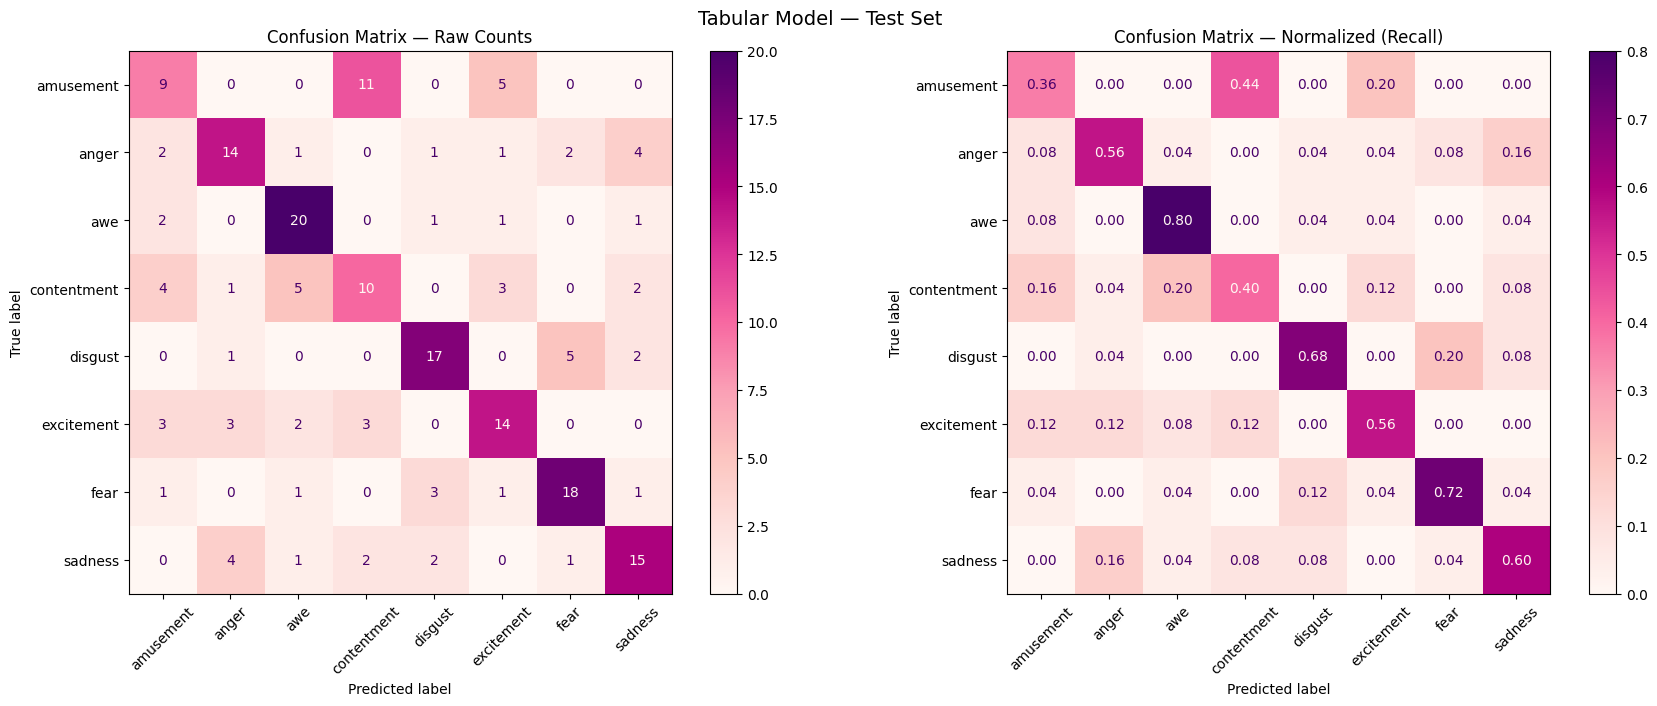

In [22]:
# Normalized confusion matrix alongside raw counts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder_order).plot(
    ax=axes[0], xticks_rotation=45, cmap='RdPu')
axes[0].set_title('Confusion Matrix — Raw Counts')

# Row-normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=encoder_order).plot(
    ax=axes[1], xticks_rotation=45, cmap='RdPu', values_format='.2f')
axes[1].set_title('Confusion Matrix — Normalized (Recall)')

plt.suptitle('Tabular Model — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

Comparing predictions of negative vs. positive emotions

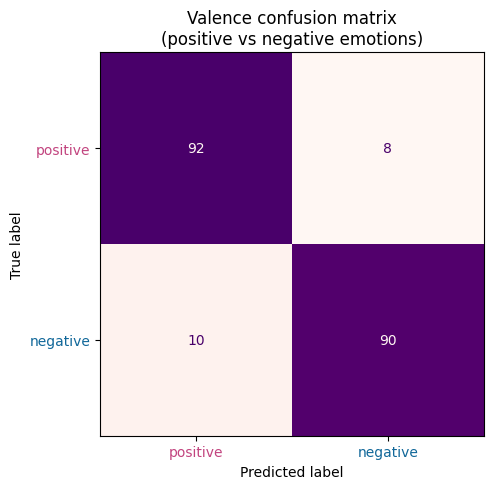

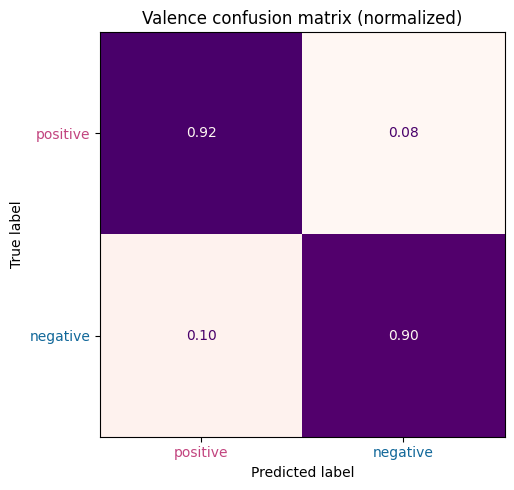

              precision    recall  f1-score   support

    positive       0.92      0.90      0.91       100
    negative       0.90      0.92      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



In [23]:
# ── 1. Map emotions to valence ────────────────────────────────────────────────
positive_emotions = ['amusement', 'excitement', 'contentment', 'awe']
negative_emotions = ['anger', 'disgust', 'fear', 'sadness']

valence_map = {e: 'positive' for e in positive_emotions}
valence_map.update({e: 'negative' for e in negative_emotions})

# Map predictions and true labels to valence
y_test_valence = [valence_map[encoder_order[i]] for i in y_test]
y_pred_valence = [valence_map[encoder_order[i]] for i in y_pred]

# ── 2. Confusion matrix ───────────────────────────────────────────────────────
# Raw values
cm_valence = confusion_matrix(y_test_valence, y_pred_valence, labels=['positive', 'negative'])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_valence, display_labels=['positive', 'negative'])
disp.plot(ax=ax, colorbar=False, cmap='RdPu', xticks_rotation=0)

# Color the tick labels by valence
ax.get_xticklabels()[0].set_color("#C2447F")
ax.get_xticklabels()[1].set_color("#106799")
ax.get_yticklabels()[0].set_color('#C2447F')
ax.get_yticklabels()[1].set_color('#106799')

plt.title('Valence confusion matrix\n(positive vs negative emotions)', fontsize=12)
plt.tight_layout()
plt.show()

# Row-normalized
cm_valence_norm = cm_valence.astype(float) / cm_valence.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_valence_norm, display_labels=['positive', 'negative'])
disp.plot(ax=ax, colorbar=False, cmap='RdPu', xticks_rotation=0, values_format='.2f')
ax.get_xticklabels()[0].set_color("#C2447F")
ax.get_xticklabels()[1].set_color("#106799")
ax.get_yticklabels()[0].set_color('#C2447F')
ax.get_yticklabels()[1].set_color('#106799')
plt.title('Valence confusion matrix (normalized)', fontsize=12)
plt.tight_layout()
plt.show()

# ── 3. Print valence-level accuracy ──────────────────────────────────────────
print(classification_report(y_test_valence, y_pred_valence, 
                            target_names=['positive', 'negative']))

Ablation analysis

desc features:    46
feel features:    61
obj features:     2
numeric features: 2
Description only           n_features=  46  acc=0.380  AUC=0.750
Viewer feelings only       n_features=  61  acc=0.560  AUC=0.894
Object only                n_features=   2  acc=0.145  AUC=0.529
Numeric only               n_features=   2  acc=0.245  AUC=0.691
Desc + Feelings            n_features= 107  acc=0.570  AUC=0.898
Text only (all)            n_features= 109  acc=0.575  AUC=0.898
All features               n_features= 111  acc=0.590  AUC=0.907


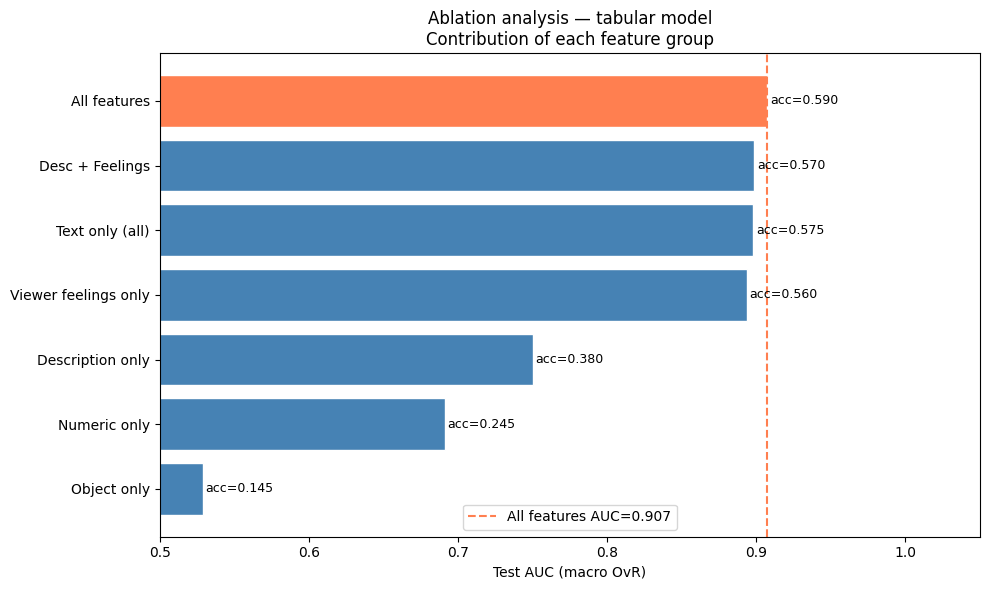

In [24]:
# ── Ablation analysis — tabular model ────────────────────────────────────────
# Reuse already-fitted tfidf_combined and existing matrices
# Slice columns by prefix to isolate each text variable's contribution

# Get feature names and identify column indices per source
all_tfidf_features = list(tfidf_combined.get_feature_names_out())
idx_desc    = [i for i, f in enumerate(all_tfidf_features) if f.startswith('desc_')]
idx_feel    = [i for i, f in enumerate(all_tfidf_features) if f.startswith('feel_')]
idx_obj     = [i for i, f in enumerate(all_tfidf_features) if f.startswith('obj_')]
idx_numeric = list(range(len(all_tfidf_features), len(feature_names)))  # brightness, colorfulness

print(f"desc features:    {len(idx_desc)}")
print(f"feel features:    {len(idx_feel)}")
print(f"obj features:     {len(idx_obj)}")
print(f"numeric features: {len(idx_numeric)}")

# Convert full train/test matrices to dense once
X_train_abl = pd.DataFrame(X_train.toarray(), columns=feature_names)
X_test_abl  = pd.DataFrame(
    hstack([test_tfidf, csr_matrix(test_numeric)]).toarray(),
    columns=feature_names
)

# ── Define ablation conditions using column slicing ───────────────────────────
all_idx = idx_desc + idx_feel + idx_obj + idx_numeric

ablation_tab_configs = {
    'Description only':     idx_desc,
    'Viewer feelings only': idx_feel,
    'Object only':          idx_obj,
    'Numeric only':         idx_numeric,
    'Desc + Feelings':      idx_desc + idx_feel,
    'Text only (all)':      idx_desc + idx_feel + idx_obj,
    'All features':         all_idx,
}

best_C_tab = best_tabular_model.get_params()['C']
y_bin_t    = label_binarize(y_test, classes=range(len(encoder_order)))

ablation_tab_results = {}
for name, col_idx in ablation_tab_configs.items():
    X_abl_train = X_train_abl.iloc[:, col_idx]
    X_abl_test  = X_test_abl.iloc[:, col_idx]
    
    model = LogisticRegression(
        penalty='l2', C=best_C_tab, solver='lbfgs',
        max_iter=1000, random_state=42
    )
    model.fit(X_abl_train, y_train)
    
    y_pred_abl = model.predict(X_abl_test)
    y_prob_abl = model.predict_proba(X_abl_test)
    
    acc     = accuracy_score(y_test, y_pred_abl)
    auc_val = roc_auc_score(y_bin_t, y_prob_abl, multi_class='ovr', average='macro')
    
    ablation_tab_results[name] = {'accuracy': acc, 'auc': auc_val}
    print(f"{name:25s}  n_features={len(col_idx):4d}  acc={acc:.3f}  AUC={auc_val:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_tab_results).T.sort_values('auc', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if n == 'All features' else 'steelblue' for n in abl_df.index]
bars = ax.barh(abl_df.index, abl_df['auc'], color=colors, edgecolor='white')

for bar, acc in zip(bars, abl_df['accuracy']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'acc={acc:.3f}', va='center', fontsize=9)

ax.axvline(ablation_tab_results['All features']['auc'],
           color='coral', linestyle='--', linewidth=1.5,
           label=f"All features AUC={ablation_tab_results['All features']['auc']:.3f}")
ax.set_xlabel('Test AUC (macro OvR)')
ax.set_title('Ablation analysis — tabular model\nContribution of each feature group')
ax.legend()
ax.set_xlim(0.5, 1.05)
plt.tight_layout()
plt.show()

## 2. Embedding model

### Applying PCA on the embedded variables

In [25]:
# Parse embedding strings to numpy arrays
train_df['embedding_parsed'] = train_df['embedding'].apply(ast.literal_eval)
train_df['desc_emb_parsed'] = train_df['description_embedding'].apply(ast.literal_eval)
train_df['feel_emb_parsed'] = train_df['viewer_feelings_embedding'].apply(ast.literal_eval)

# Stack into matrices
E_image = np.stack(train_df['embedding_parsed'].values)         # image CLIP embedding
E_desc  = np.stack(train_df['desc_emb_parsed'].values)          # description text embedding
E_feel  = np.stack(train_df['feel_emb_parsed'].values)          # viewer feelings text embedding

print(f"Image embedding shape:       {E_image.shape}")
print(f"Description embedding shape: {E_desc.shape}")
print(f"Feelings embedding shape:    {E_feel.shape}")
# Expect something like (800, 512) or (800, 1536) depending on the model used

Image embedding shape:       (800, 512)
Description embedding shape: (800, 1536)
Feelings embedding shape:    (800, 1536)


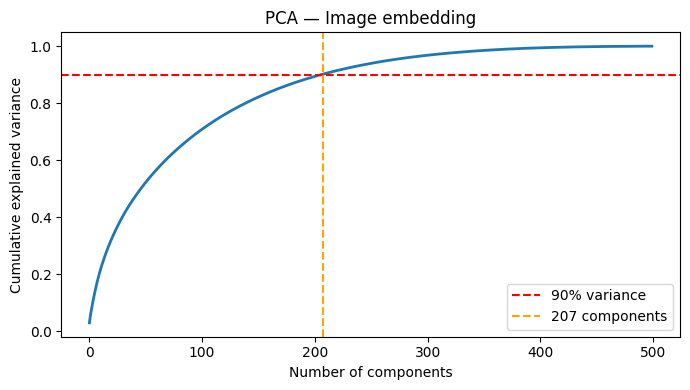

Image embedding: 90% variance reached at 207 components


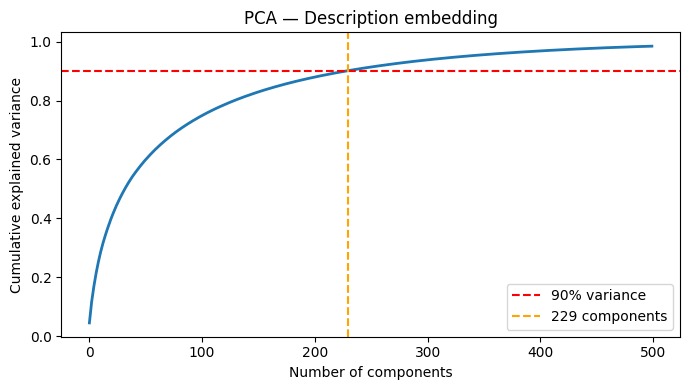

Description embedding: 90% variance reached at 229 components


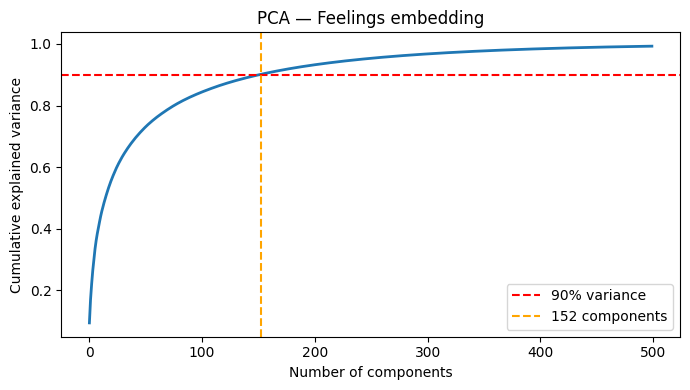

Feelings embedding: 90% variance reached at 152 components


In [26]:
# ── 1. Standardize each embedding separately ─────────────────────────────────
# Important before PCA - embeddings may have different scales
scaler_image = StandardScaler()
scaler_desc  = StandardScaler()
scaler_feel  = StandardScaler()

E_image_scaled = scaler_image.fit_transform(E_image)
E_desc_scaled  = scaler_desc.fit_transform(E_desc)
E_feel_scaled  = scaler_feel.fit_transform(E_feel)

# ── 2. PCA on each embedding separately ──────────────────────────────────────
# Keep enough components to explain ~90% variance
def fit_pca_with_plot(X, name, max_components=500):
    pca = PCA(n_components=max_components)
    pca.fit(X)
    
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_90 = np.argmax(cumvar >= 0.90) + 1
    
    plt.figure(figsize=(7, 4))
    plt.plot(cumvar, linewidth=2)
    plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
    plt.axvline(n_90, color='orange', linestyle='--', label=f'{n_90} components')
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance')
    plt.title(f'PCA — {name}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    if n_90 == 1 and cumvar[0] < 0.90:
        n_90 = max_components
        print(f"{name}: 90% variance not reached in {max_components} components, using all {max_components}")
    else:
        print(f"{name}: 90% variance reached at {n_90} components")
        
    return pca, n_90

pca_image, n_image = fit_pca_with_plot(E_image_scaled, 'Image embedding')
pca_desc,  n_desc  = fit_pca_with_plot(E_desc_scaled,  'Description embedding')
pca_feel,  n_feel  = fit_pca_with_plot(E_feel_scaled,  'Feelings embedding')

### Selecting the number of PCA components via CV
Before comparing models, we select the optimal number of PCA components for each embedding using cross-validated AUC with Logistic Regression as a proxy evaluator.

**Methodological note:** PCA is fit on the full training set before CV, which introduces mild optimistic bias in the CV estimates. Final performance is evaluated on the held-out test set.

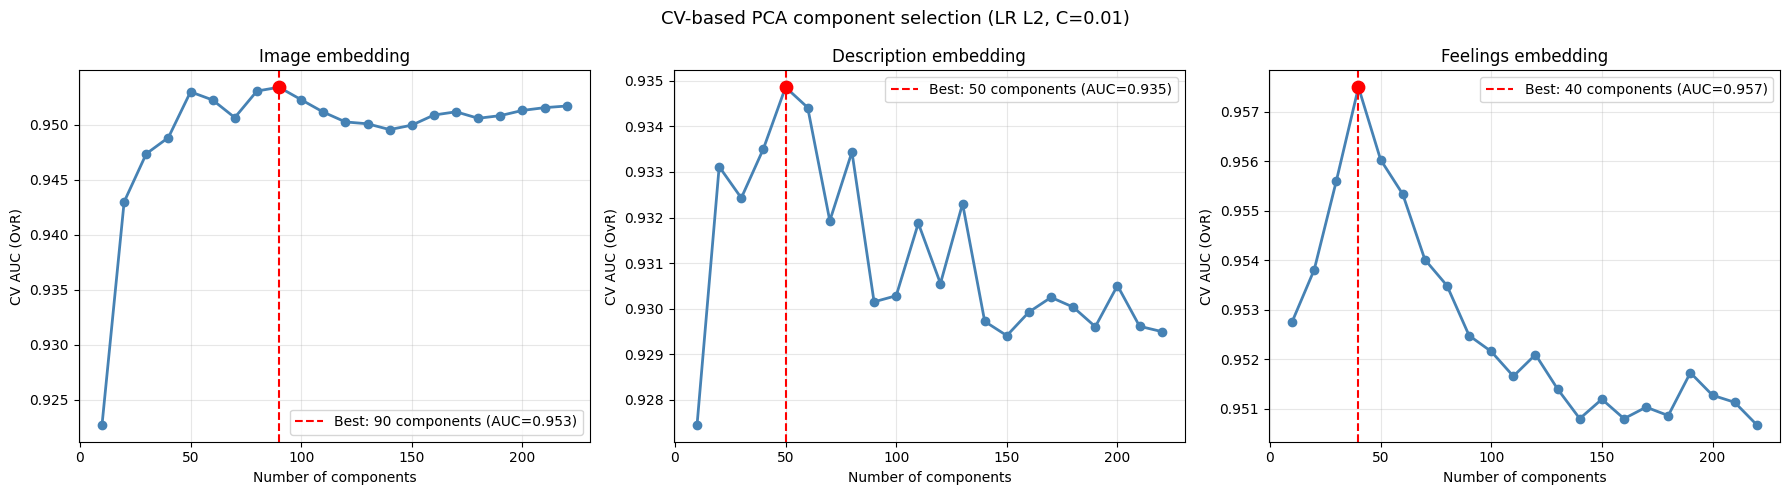

Components selected — image: 90, description: 50, feelings: 40


In [27]:
# # ── CV-based PCA component selection ─────────────────────────────────────────
n_components_to_try = range(10, 230, 10)
cv_components = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (E_scaled, name) in zip(axes, [
    (E_image_scaled, 'Image embedding'),
    (E_desc_scaled,  'Description embedding'),
    (E_feel_scaled,  'Feelings embedding')
]):
    auc_scores = []
    
    for n in n_components_to_try:
        pca_temp = PCA(n_components=n, random_state=42).fit(E_scaled)
        X_temp = pca_temp.transform(E_scaled)
        
        score = cross_val_score(
            LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000, random_state=42),
            X_temp, y_train, cv=cv, scoring='roc_auc_ovr'
        ).mean()
        auc_scores.append(score)
    
    # Best n for this embedding
    best_n_comp = list(n_components_to_try)[np.argmax(auc_scores)]
    cv_components[name] = best_n_comp
    
    # Plot
    ax.plot(list(n_components_to_try), auc_scores, marker='o', linewidth=2, color='steelblue')
    ax.axvline(best_n_comp, color='red', linestyle='--', linewidth=1.5,
               label=f'Best: {best_n_comp} components (AUC={max(auc_scores):.3f})')
    ax.scatter([best_n_comp], [max(auc_scores)], color='red', s=80, zorder=5)
    ax.set_xlabel('Number of components')
    ax.set_ylabel('CV AUC (OvR)')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('CV-based PCA component selection (LR L2, C=0.01)', fontsize=13)
plt.tight_layout()
plt.show()

n_image_final = cv_components['Image embedding']
n_desc_final  = cv_components['Description embedding']
n_feel_final  = cv_components['Feelings embedding']

print(f"Components selected — image: {n_image_final}, description: {n_desc_final}, feelings: {n_feel_final}")

### Model comparison on CV-selected PCA features
We now compare classifiers on the embedding features with the CV-selected number of PCA components. We include Gradient Boosting instead of KNN, since after PCA the features are dense and continuous — an environment where gradient boosting excels, while KNN suffers from the curse of dimensionality in the remaining ~100+ dimensional space.

In [28]:
X_emb = np.hstack([
    pca_image.transform(E_image_scaled)[:, :n_image_final],
    pca_desc.transform(E_desc_scaled)[:, :n_desc_final],
    pca_feel.transform(E_feel_scaled)[:, :n_feel_final]
])
print(f"Embedding feature matrix shape: {X_emb.shape}")

coarse_grids = {
    'Logistic Regression (L2)': (
        LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Logistic Regression (L1)': (
        LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 10]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': list(range(1, 20, 2))}
    ),
}

emb_results = {}
for name, (model, grid) in coarse_grids.items():
    gs = GridSearchCV(model, grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
    gs.fit(X_emb, y_train)
    
    # Get CV accuracy for the best params
    acc = cross_val_score(gs.best_estimator_, X_emb, y_train, cv=cv, scoring='accuracy').mean()
    
    emb_results[name] = {
        'accuracy':       acc,
        'auc':            gs.best_score_,
        'best_params':    gs.best_params_,
        'best_estimator': gs.best_estimator_
    }
    print(f"{name:30s}  acc={acc:.3f}  auc={gs.best_score_:.3f}  params={gs.best_params_}")

# ── Select best model by AUC ──────────────────────────────────────────────────
best_emb_name = max(emb_results, key=lambda x: emb_results[x]['auc'])
best_emb_model = emb_results[best_emb_name]['best_estimator']
print(f"\nBest model: {best_emb_name}  AUC={emb_results[best_emb_name]['auc']:.3f}")

Embedding feature matrix shape: (800, 180)
Logistic Regression (L2)        acc=0.766  auc=0.959  params={'C': 0.01}
Logistic Regression (L1)        acc=0.755  auc=0.960  params={'C': 0.1}
Random Forest                   acc=0.759  auc=0.963  params={'max_depth': None, 'n_estimators': 200}
Gradient Boosting               acc=0.706  auc=0.940  params={'max_depth': 3, 'n_estimators': 100}
KNN                             acc=0.736  auc=0.951  params={'n_neighbors': 17}

Best model: Random Forest  AUC=0.963


We select the best model by macro OvR AUC rather than accuracy because AUC captures the model's ability to discriminate between classes across all decision thresholds, making it more robust to class imbalance and more informative for soft-prediction tasks. Accuracy penalizes miscalibrated confidence even when the ranking is correct.

The AUC > accuracy pattern exists with embeddings too. The CLIP and text embeddings capture semantic similarity between emotions, so the probability distributions tend to peak around semantically related classes. The model successfully separates positive from negative valence but confuses within-valence categories (e.g., fear vs. anger, amusement vs. excitement), consistent with dimensional models of emotion in affective neuroscience.

Visualize model comparison

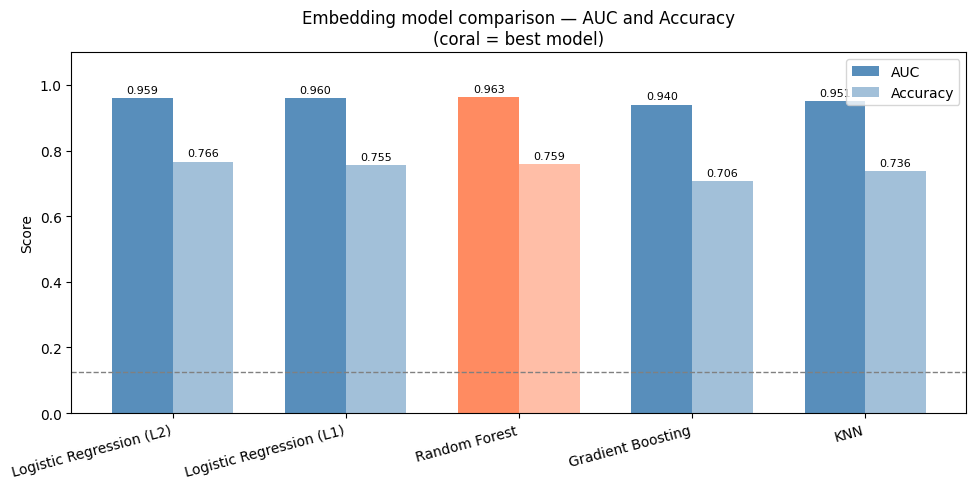

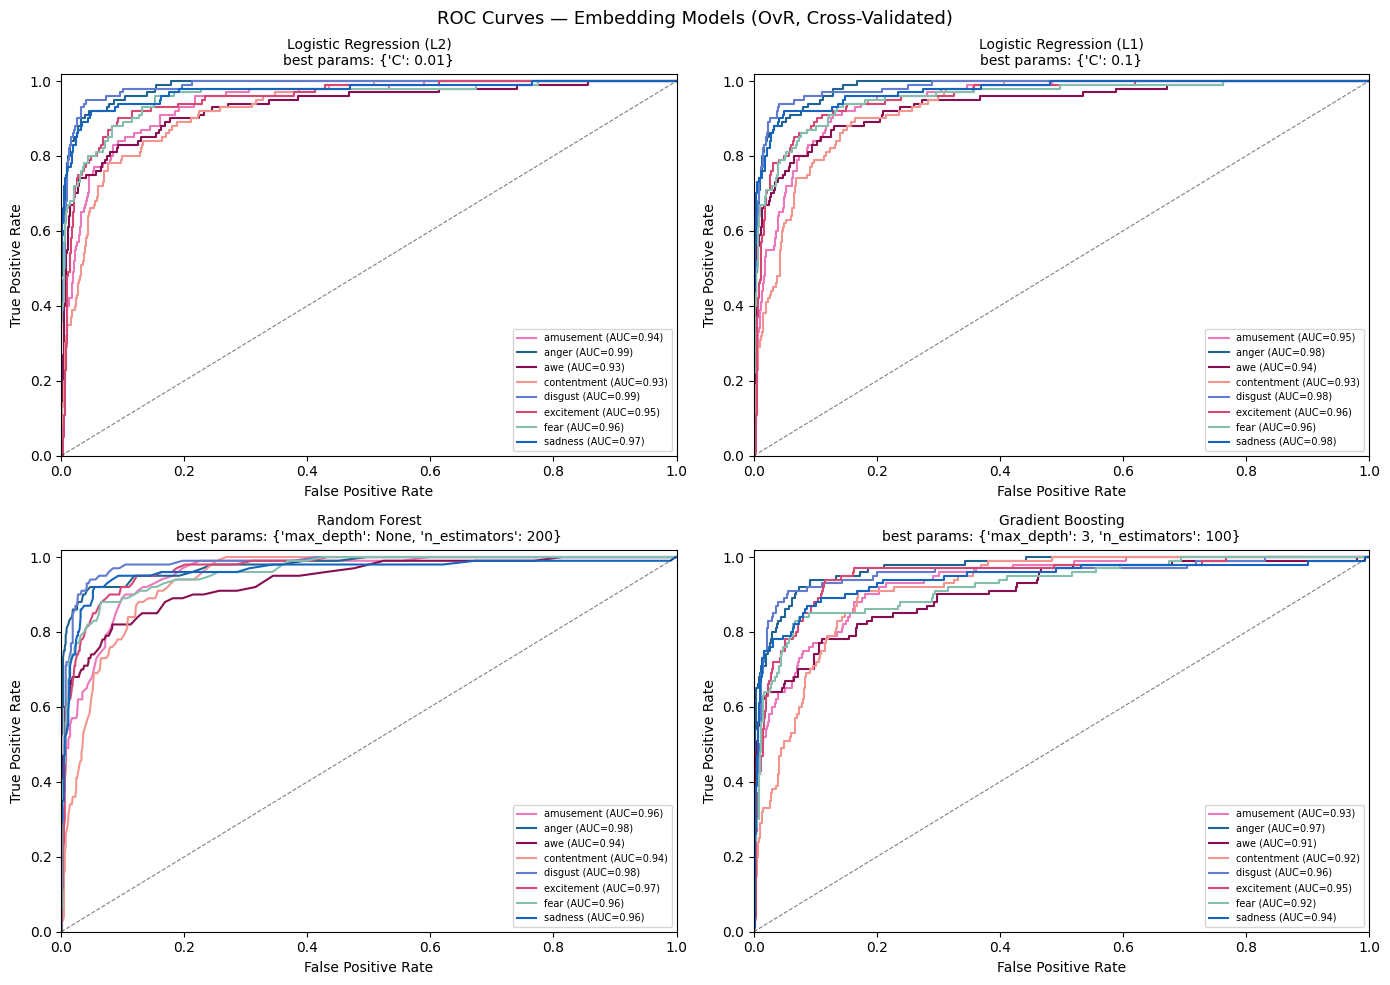

In [29]:
# ── Plot 1: Bar chart with error bars ─────────────────────────────────────────
names  = list(emb_results.keys())
aucs   = [emb_results[n]['auc'] for n in names]
accs   = [emb_results[n]['accuracy'] for n in names]
colors = ['coral' if n == best_emb_name else 'steelblue' for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, aucs, width, label='AUC',      color=colors, alpha=0.9)
bars2 = ax.bar(x + width/2, accs, width, label='Accuracy', color=colors, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Embedding model comparison — AUC and Accuracy\n(coral = best model)')
ax.legend()
ax.axhline(1/8, color='gray', linestyle='--', linewidth=1, label='Random chance')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────
y_bin = label_binarize(y_train, classes=range(len(encoder_order)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, metrics) in zip(axes, emb_results.items()):
    y_prob = cross_val_predict(
        metrics['best_estimator'], X_emb, y_train, cv=cv, method='predict_proba'
    )
    for i, emotion in enumerate(encoder_order):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=emotion_colors[emotion], linewidth=1.5,
                label=f"{emotion} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(f"{name}\nbest params: {metrics['best_params']}", fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — Embedding Models (OvR, Cross-Validated)', fontsize=13)
plt.tight_layout()
plt.show()

The model is better at ranking and separating emotions from each other (high AUC)
than at making final predictions (lower accuracy, but still good)
This typically happens when classes overlap in the embedding space — the model knows "this image is more fear-like than amusement-like" but isn't confident enough to commit to a single label

Apply preproccessing of embeddings on the test set

In [30]:
# ── Preprocess test embeddings ────────────────────────────────────────────────
test_df['embedding_parsed'] = test_df['embedding'].apply(ast.literal_eval)
test_df['desc_emb_parsed']  = test_df['description_embedding'].apply(ast.literal_eval)
test_df['feel_emb_parsed']  = test_df['viewer_feelings_embedding'].apply(ast.literal_eval)

E_image_test = np.stack(test_df['embedding_parsed'].values)
E_desc_test  = np.stack(test_df['desc_emb_parsed'].values)
E_feel_test  = np.stack(test_df['feel_emb_parsed'].values)

# Scale using train scalers (transform only, never fit)
E_image_test_scaled = scaler_image.transform(E_image_test)
E_desc_test_scaled  = scaler_desc.transform(E_desc_test)
E_feel_test_scaled  = scaler_feel.transform(E_feel_test)

In [31]:
# # ── Build test embedding features ────────────────────────────────────────────
X_emb_test = np.hstack([
    pca_image.transform(E_image_test_scaled)[:, :n_image_final],
    pca_desc.transform(E_desc_test_scaled)[:, :n_desc_final],
    pca_feel.transform(E_feel_test_scaled)[:, :n_feel_final]
])

print(f"Train: {X_emb.shape}")
print(f"Test:  {X_emb_test.shape}")
assert X_emb.shape[1] == X_emb_test.shape[1], "Shape mismatch!"

# ── Refit on full train and evaluate on test ─────────────────────────────────
best_emb_model = emb_results[best_emb_name]['best_estimator']
best_emb_model.fit(X_emb, y_train)

y_pred_emb = best_emb_model.predict(X_emb_test)
y_prob_emb = best_emb_model.predict_proba(X_emb_test)

accuracy_emb  = accuracy_score(y_test, y_pred_emb)
precision_emb = precision_score(y_test, y_pred_emb, average='macro', zero_division=0)
recall_emb    = recall_score(y_test, y_pred_emb, average='macro', zero_division=0)

y_bin_test = label_binarize(y_test, classes=range(len(encoder_order)))
test_auc_emb = roc_auc_score(y_bin_test, y_prob_emb, multi_class='ovr', average='macro')

print(f"\nEmbedding model — Test Set Results ({best_emb_name})")
print(f"  Accuracy:          {accuracy_emb:.3f}")
print(f"  Precision (macro): {precision_emb:.3f}")
print(f"  Recall (macro):    {recall_emb:.3f}")
print(f"  AUC (macro OvR):   {test_auc_emb:.3f}")

Train: (800, 180)
Test:  (200, 180)

Embedding model — Test Set Results (Random Forest)
  Accuracy:          0.695
  Precision (macro): 0.723
  Recall (macro):    0.695
  AUC (macro OvR):   0.948


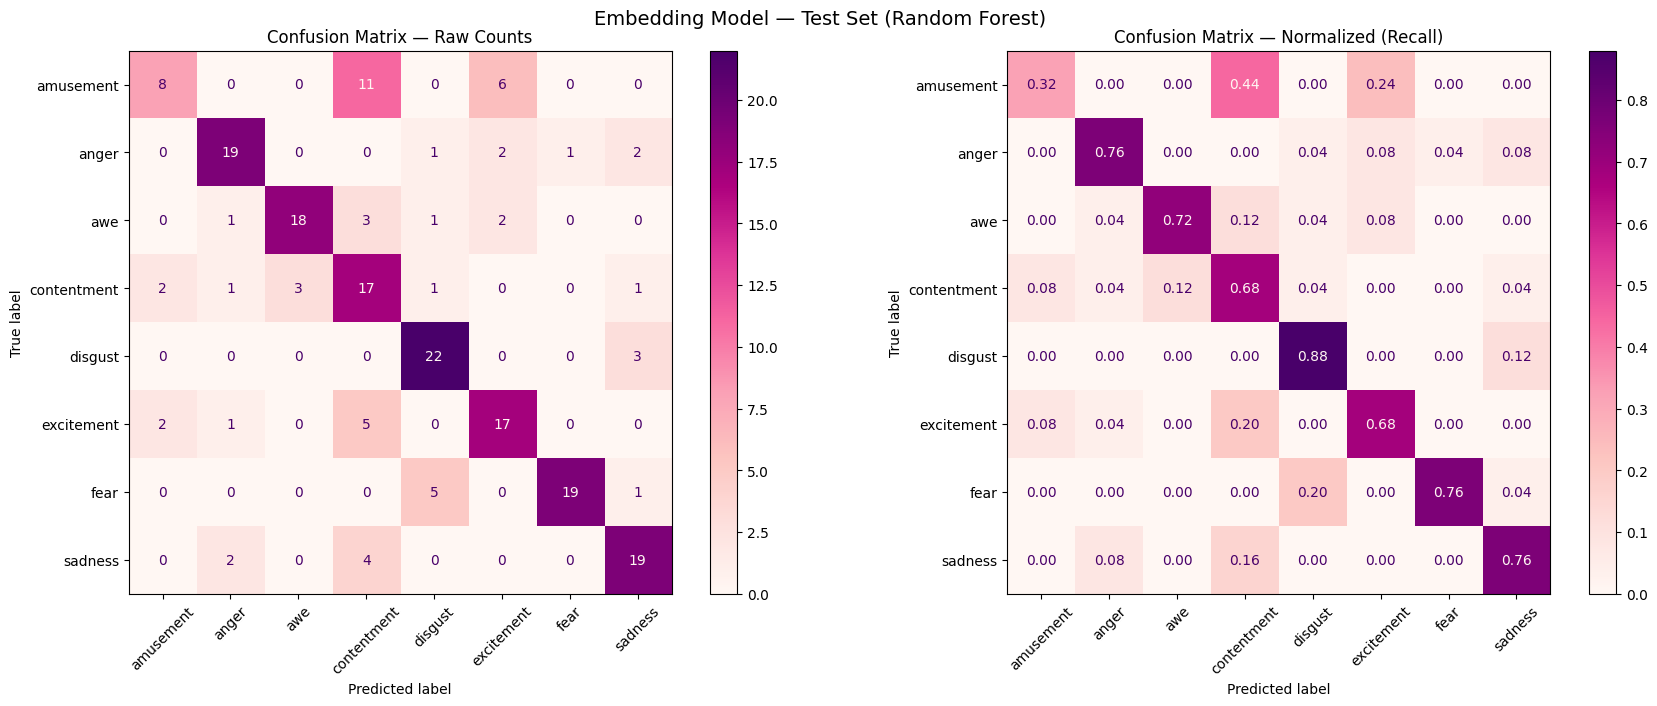

In [32]:
# Normalized and raw confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm = confusion_matrix(y_test, y_pred_emb)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder_order).plot(
    ax=axes[0], xticks_rotation=45, cmap='RdPu')
axes[0].set_title('Confusion Matrix — Raw Counts')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=encoder_order).plot(
    ax=axes[1], xticks_rotation=45, cmap='RdPu', values_format='.2f')
axes[1].set_title('Confusion Matrix — Normalized (Recall)')

plt.suptitle(f'Embedding Model — Test Set ({best_emb_name})', fontsize=14)
plt.tight_layout()
plt.show()

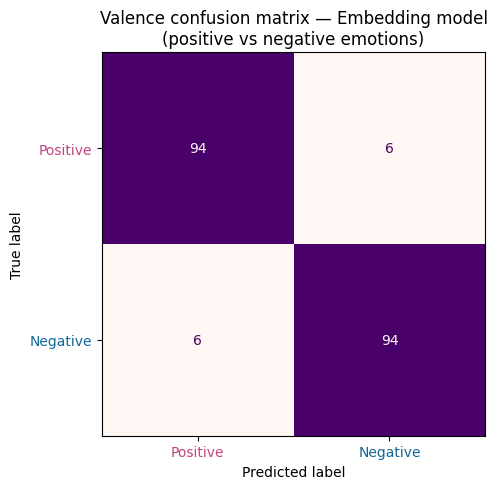

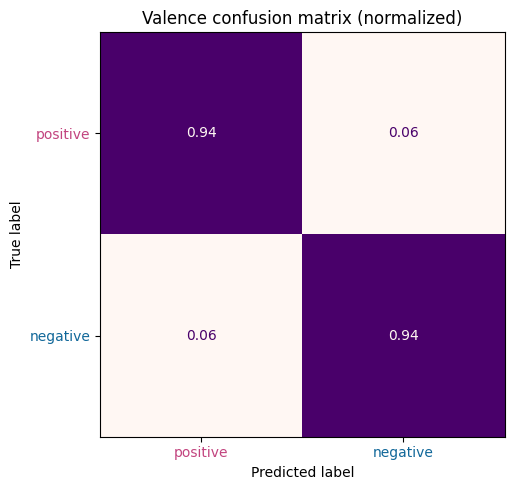

              precision    recall  f1-score   support

    positive       0.94      0.94      0.94       100
    negative       0.94      0.94      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



In [33]:
# Map predictions and true labels to valence
y_test_emb_valence = [valence_map[encoder_order[i]] for i in y_test]
y_pred_emb_valence = [valence_map[encoder_order[i]] for i in y_pred_emb]  # y_pred_emb not y_pred

# Confusion matrix for valence
# Raw values
cm_emb_valence = confusion_matrix(y_test_emb_valence, y_pred_emb_valence, 
                                   labels=['positive', 'negative'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_emb_valence, 
                               display_labels=['Positive', 'Negative'])
disp.plot(ax=ax, colorbar=False, cmap='RdPu', xticks_rotation=0)

ax.get_xticklabels()[0].set_color("#C2447F")
ax.get_xticklabels()[1].set_color("#106799")
ax.get_yticklabels()[0].set_color('#C2447F')
ax.get_yticklabels()[1].set_color('#106799')

plt.title('Valence confusion matrix — Embedding model\n(positive vs negative emotions)', fontsize=12)
plt.tight_layout()
plt.show()

# Row-normalized
cm_emb_valence_norm = cm_emb_valence.astype(float) / cm_emb_valence.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_emb_valence_norm, display_labels=['positive', 'negative'])
disp.plot(ax=ax, colorbar=False, cmap='RdPu', xticks_rotation=0, values_format='.2f')
ax.get_xticklabels()[0].set_color("#C2447F")
ax.get_xticklabels()[1].set_color("#106799")
ax.get_yticklabels()[0].set_color('#C2447F')
ax.get_yticklabels()[1].set_color('#106799')
plt.title('Valence confusion matrix (normalized)', fontsize=12)
plt.tight_layout()
plt.show()

print(classification_report(y_test_emb_valence, y_pred_emb_valence,
                            target_names=['positive', 'negative']))

## Confusion Matrix Analysis: Which Emotions Are Hardest to Classify?

Examining the confusion matrices of both models reveals consistent patterns that align with affective neuroscience theory.

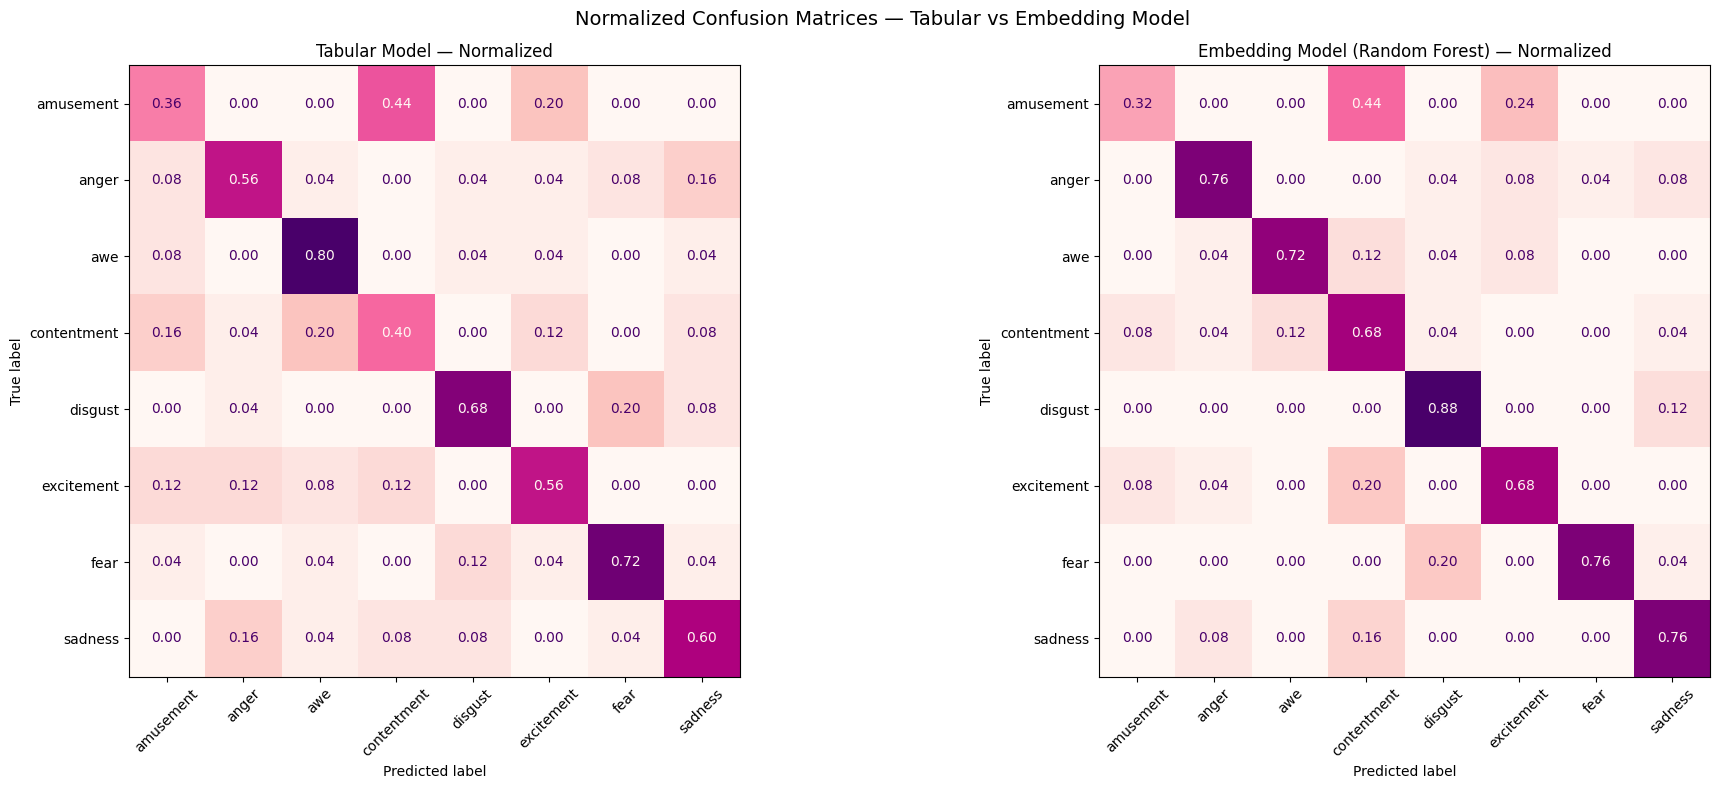

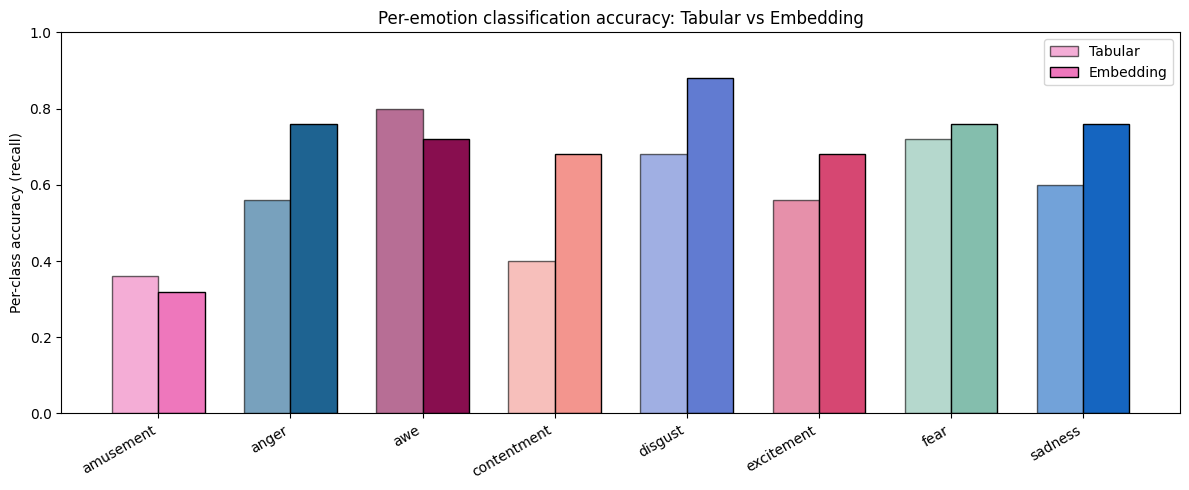

In [34]:
# Side-by-side normalized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_tab = confusion_matrix(y_test, y_pred)
cm_tab_norm = cm_tab.astype(float) / cm_tab.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_tab_norm, display_labels=encoder_order).plot(
    ax=axes[0], xticks_rotation=45, cmap='RdPu', colorbar=False, values_format='.2f')
axes[0].set_title('Tabular Model — Normalized', fontsize=12)

cm_emb = confusion_matrix(y_test, y_pred_emb)
cm_emb_norm = cm_emb.astype(float) / cm_emb.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_emb_norm, display_labels=encoder_order).plot(
    ax=axes[1], xticks_rotation=45, cmap='RdPu', colorbar=False, values_format='.2f')
axes[1].set_title(f'Embedding Model ({best_emb_name}) — Normalized', fontsize=12)

plt.suptitle('Normalized Confusion Matrices — Tabular vs Embedding Model', fontsize=14)
plt.tight_layout()
plt.show()

# ── Per-emotion accuracy comparison ──────────────────────────────────────────
cm_tab_raw = confusion_matrix(y_test, y_pred)
cm_emb_raw = confusion_matrix(y_test, y_pred_emb)
per_emotion_tab = cm_tab_raw.diagonal() / cm_tab_raw.sum(axis=1)
per_emotion_emb = cm_emb_raw.diagonal() / cm_emb_raw.sum(axis=1)

x = np.arange(len(encoder_order))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, per_emotion_tab, width, label='Tabular',
               color=[emotion_colors[e] for e in encoder_order], alpha=0.6, edgecolor='black')
bars2 = ax.bar(x + width/2, per_emotion_emb, width, label='Embedding',
               color=[emotion_colors[e] for e in encoder_order], alpha=1.0, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(encoder_order, rotation=30, ha='right')
ax.set_ylabel('Per-class accuracy (recall)')
ax.set_title('Per-emotion classification accuracy: Tabular vs Embedding')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Several patterns emerge from the confusion matrices:

**Within-valence confusions dominate.** Both models more often confuse emotions that share the same valence — e.g., *awe* and *excitement* (both high-arousal positive), or *anger* and *disgust* (both high-arousal negative). This is consistent with the Mikels model, where emotions within the same valence–arousal quadrant share visual features.

**Low-arousal emotions are hardest.** *Contentment* (positive, low-arousal) and *sadness* (negative, low-arousal) tend to have lower per-class recall. Low-arousal emotions are conveyed through subtler visual cues, making them harder to distinguish.

**The embedding model generalized better to held-out data**, suggesting that pretrained semantic representations capture emotional content more effectively than sparse interpretable features. Conversely, the tabular model remained interpretable, but some of its strongest predictors came from GPT-generated textual descriptions of likely viewer emotions, which are semantically close to the target labels and therefore likely carry high-level emotion priors.

**Clustering revealed partial but incomplete alignment with the labeled emotion structure.** The low silhouette score suggests substantial overlap between emotion categories in the combined embedding space.

## Ablation Analysis
*We evaluate the best model (Logistic Regression L2) on subsets of the embedding features to understand the relative contribution of each embedding source. This uses the same PCA components and model hyperparameters selected above.*

Image only            features=  90  acc=0.645  AUC=0.921
Description only      features=  50  acc=0.610  AUC=0.914
Feelings only         features=  40  acc=0.695  AUC=0.932
Image + Desc          features= 140  acc=0.645  AUC=0.925
Image + Feel          features= 130  acc=0.695  AUC=0.937
Desc + Feel           features=  90  acc=0.635  AUC=0.926
All three             features= 180  acc=0.690  AUC=0.942


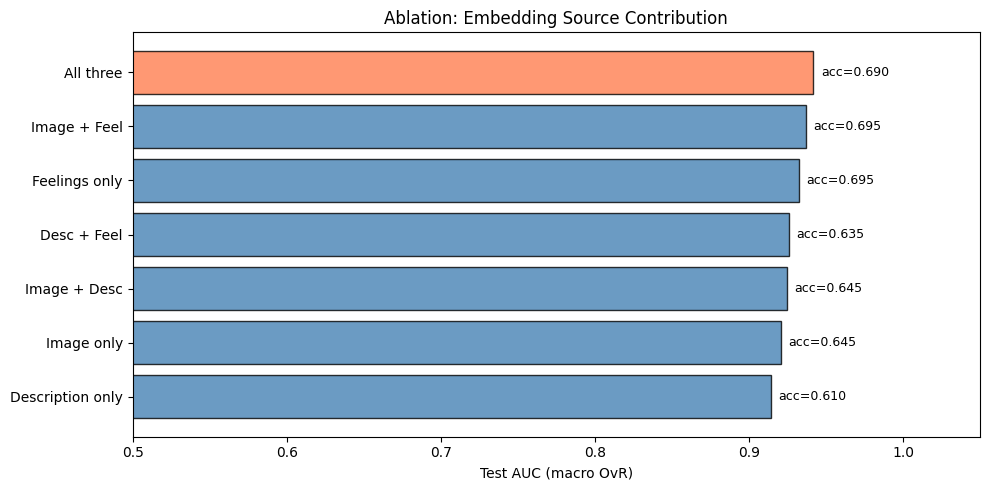

In [35]:
# [ADDED] Ablation analysis — embedding model
# Which embedding sources contribute most?

ablation_configs = {
    'Image only':       (E_image_scaled, pca_image, n_image_final),
    'Description only': (E_desc_scaled,  pca_desc,  n_desc_final),
    'Feelings only':    (E_feel_scaled,  pca_feel,  n_feel_final),
    'Image + Desc':     None,  # handled below
    'Image + Feel':     None,
    'Desc + Feel':      None,
    'All three':        None,
}

def get_emb_features(configs_list):
    """Build feature matrix from a list of (scaled_data, pca, n_comp) tuples."""
    parts = [pca.transform(data)[:, :n] for data, pca, n in configs_list]
    return np.hstack(parts)

def get_emb_test_features(configs_list, test_data_list):
    parts = [pca.transform(data)[:, :n] for (_, pca, n), data in zip(configs_list, test_data_list)]
    return np.hstack(parts)

single_sources = {
    'Image only':       [(E_image_scaled, pca_image, n_image_final)],
    'Description only': [(E_desc_scaled, pca_desc, n_desc_final)],
    'Feelings only':    [(E_feel_scaled, pca_feel, n_feel_final)],
    'Image + Desc':     [(E_image_scaled, pca_image, n_image_final), (E_desc_scaled, pca_desc, n_desc_final)],
    'Image + Feel':     [(E_image_scaled, pca_image, n_image_final), (E_feel_scaled, pca_feel, n_feel_final)],
    'Desc + Feel':      [(E_desc_scaled, pca_desc, n_desc_final), (E_feel_scaled, pca_feel, n_feel_final)],
    'All three':        [(E_image_scaled, pca_image, n_image_final), (E_desc_scaled, pca_desc, n_desc_final), (E_feel_scaled, pca_feel, n_feel_final)],
}

test_source_data = {
    'Image only':       [E_image_test_scaled],
    'Description only': [E_desc_test_scaled],
    'Feelings only':    [E_feel_test_scaled],
    'Image + Desc':     [E_image_test_scaled, E_desc_test_scaled],
    'Image + Feel':     [E_image_test_scaled, E_feel_test_scaled],
    'Desc + Feel':      [E_desc_test_scaled, E_feel_test_scaled],
    'All three':        [E_image_test_scaled, E_desc_test_scaled, E_feel_test_scaled],
}

ablation_results = {}
best_C = emb_results[best_emb_name]['best_params'].get('C', 1)

for name, configs in single_sources.items():
    X_abl_train = get_emb_features(configs)
    X_abl_test  = get_emb_test_features(configs, test_source_data[name])
    
    model = LogisticRegression(penalty='l2', C=best_C, solver='lbfgs', max_iter=1000, random_state=42)
    model.fit(X_abl_train, y_train)
    
    y_pred_abl = model.predict(X_abl_test)
    y_prob_abl = model.predict_proba(X_abl_test)
    
    acc = accuracy_score(y_test, y_pred_abl)
    y_bin_t = label_binarize(y_test, classes=range(len(encoder_order)))
    auc_val = roc_auc_score(y_bin_t, y_prob_abl, multi_class='ovr', average='macro')
    
    ablation_results[name] = {'accuracy': acc, 'auc': auc_val, 'n_features': X_abl_train.shape[1]}
    print(f"{name:20s}  features={X_abl_train.shape[1]:4d}  acc={acc:.3f}  AUC={auc_val:.3f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
abl_df = abl_df.sort_values('auc', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['coral' if n == 'All three' else 'steelblue' for n in abl_df.index]
bars = ax.barh(abl_df.index, abl_df['auc'], color=colors, edgecolor='black', alpha=0.8)
for bar, acc in zip(bars, abl_df['accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'acc={acc:.3f}', va='center', fontsize=9)
ax.set_xlabel('Test AUC (macro OvR)')
ax.set_title('Ablation: Embedding Source Contribution')
ax.set_xlim(0.5, 1.05)
plt.tight_layout()
plt.show()

The ablation analysis shows the relative contribution of each embedding source. The viewer-feelings embedding typically provides the strongest single-source signal, consistent with the fact that it is semantically closest to the emotion labels. Combining all three sources yields the best performance, indicating complementary information across modalities.

# Conclusions: Tabular vs. Embedding Model Comparison

In [36]:
# Bootstrap confidence intervals and per-class AUC table
def bootstrap_metric(y_true, y_pred_or_prob, metric_fn, n_boot=1000, **kwargs):
    """Compute bootstrap 95% CI for a metric."""
    scores = []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=None)
        try:
            scores.append(metric_fn(y_true[idx], y_pred_or_prob[idx], **kwargs))
        except Exception:
            continue
    return np.percentile(scores, [2.5, 97.5])

y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)
y_pred_emb_arr = np.array(y_pred_emb)
y_prob_test_arr = np.array(y_prob_test)
y_prob_emb_arr = np.array(y_prob_emb)

# ── Tabular metrics + CIs ────────────────────────────────────────────────────
tab_accuracy  = accuracy_score(y_test, y_pred)
tab_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
tab_recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
y_bin_test_tab = label_binarize(y_test, classes=range(len(encoder_order)))
tab_auc = roc_auc_score(y_bin_test_tab, y_prob_test, multi_class='ovr', average='macro')

tab_acc_ci  = bootstrap_metric(y_test_arr, y_pred_arr, accuracy_score)

def _auc_macro(y_t, y_p):
    yb = label_binarize(y_t, classes=range(len(encoder_order)))
    return roc_auc_score(yb, y_p, multi_class='ovr', average='macro')

tab_auc_ci = bootstrap_metric(y_test_arr, y_prob_test_arr, _auc_macro)

# ── Embedding metrics + CIs ──────────────────────────────────────────────────
emb_acc_ci = bootstrap_metric(y_test_arr, y_pred_emb_arr, accuracy_score)
emb_auc_ci = bootstrap_metric(y_test_arr, y_prob_emb_arr, _auc_macro)

# ── Summary table ─────────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'AUC (macro OvR)'],
    'Tabular': [
        f'{tab_accuracy:.3f} [{tab_acc_ci[0]:.3f}, {tab_acc_ci[1]:.3f}]',
        f'{tab_precision:.3f}',
        f'{tab_recall:.3f}',
        f'{tab_auc:.3f} [{tab_auc_ci[0]:.3f}, {tab_auc_ci[1]:.3f}]'
    ],
    f'Embedding ({best_emb_name})': [
        f'{accuracy_emb:.3f} [{emb_acc_ci[0]:.3f}, {emb_acc_ci[1]:.3f}]',
        f'{precision_emb:.3f}',
        f'{recall_emb:.3f}',
        f'{test_auc_emb:.3f} [{emb_auc_ci[0]:.3f}, {emb_auc_ci[1]:.3f}]'
    ]
})
print("Test-set performance (95% bootstrap CI where shown):")
print(comparison_df.to_string(index=False))

# ── Per-class AUC table ──────────────────────────────────────────────────────
y_bin_test = label_binarize(y_test, classes=range(len(encoder_order)))
per_class_auc_tab = []
per_class_auc_emb = []
for i, emotion in enumerate(encoder_order):
    auc_t = roc_auc_score(y_bin_test[:, i], y_prob_test_arr[:, i])
    auc_e = roc_auc_score(y_bin_test[:, i], y_prob_emb_arr[:, i])
    per_class_auc_tab.append(auc_t)
    per_class_auc_emb.append(auc_e)

auc_table = pd.DataFrame({
    'Emotion': encoder_order,
    'Tabular AUC': [f'{a:.3f}' for a in per_class_auc_tab],
    'Embedding AUC': [f'{a:.3f}' for a in per_class_auc_emb],
})
print("\nPer-class AUC (OvR):")
print(auc_table.to_string(index=False))

# ── Valence-level comparison ─────────────────────────────────────────────────
positive_emotions = ['amusement', 'excitement', 'contentment', 'awe']
negative_emotions = ['anger', 'disgust', 'fear', 'sadness']
valence_map = {e: 'positive' for e in positive_emotions}
valence_map.update({e: 'negative' for e in negative_emotions})

y_test_val = [valence_map[encoder_order[i]] for i in y_test]
y_pred_tab_val = [valence_map[encoder_order[i]] for i in y_pred]
y_pred_emb_val = [valence_map[encoder_order[i]] for i in y_pred_emb]

tab_val_acc = accuracy_score(y_test_val, y_pred_tab_val)
emb_val_acc = accuracy_score(y_test_val, y_pred_emb_val)

print(f"\nValence-level accuracy (positive vs negative):")
print(f"  Tabular:   {tab_val_acc:.3f}")
print(f"  Embedding: {emb_val_acc:.3f}")

Test-set performance (95% bootstrap CI where shown):
           Metric              Tabular Embedding (Random Forest)
         Accuracy 0.585 [0.515, 0.650]      0.695 [0.630, 0.755]
Precision (macro)                0.581                     0.723
   Recall (macro)                0.585                     0.695
  AUC (macro OvR) 0.903 [0.878, 0.926]      0.948 [0.933, 0.963]

Per-class AUC (OvR):
    Emotion Tabular AUC Embedding AUC
  amusement       0.871         0.869
      anger       0.887         0.979
        awe       0.943         0.967
contentment       0.871         0.921
    disgust       0.911         0.962
 excitement       0.904         0.943
       fear       0.925         0.968
    sadness       0.909         0.978

Valence-level accuracy (positive vs negative):
  Tabular:   0.910
  Embedding: 0.940


The table above summarizes test-set performance of both approaches, with bootstrap 95% confidence intervals. Key takeaways:

**The embedding model generalized better to held-out data**, suggesting that pretrained semantic representations (CLIP image embeddings and text embeddings) capture richer emotional content than sparse TF-IDF features combined with two numeric metadata variables.

**The tabular model remained interpretable.** SHAP analysis highlighted the most influential features for the fitted tabular model — notably, many of its strongest predictors came from GPT-generated viewer-feeling descriptions, which are semantically close to the target labels and therefore likely carry high-level emotion priors.

**Both models separated positive from negative valence more reliably than fine-grained emotion categories**, consistent with the dimensional model of affect in affective neuroscience. This suggests that the boundary between coarse valence and fine-grained emotion categories is where prediction difficulty concentrates.

**The success of a linear classifier on PCA-reduced embeddings** suggests that the class structure is already represented relatively linearly in the pretrained embedding spaces — a complex nonlinear model was not required to exploit it.

**Limitations.** Several preprocessing steps (TF-IDF fitting, PCA, SHAP-based feature ranking) were performed on the full training set before cross-validation, so the reported CV metrics may carry mild optimistic bias. The final conclusions rely primarily on the held-out test set, which was kept strictly separate throughout.